In [1]:
import sys
import uproot
import ROOT as r
import numpy as np
import array as arr
import awkward as ak
import os
import matplotlib.pyplot as plt
#from analysis import Analysis
import logging
import pickle
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
os.environ['MEDULLA_PLOT_DIR'] =  '/nashome/m/micarrig/icarus/nuESpine/medulla/spineplot/'
sys.path.append('/nashome/m/micarrig/icarus/nuESpine/medulla/spineplot/')
from efficiency import SpineEfficiency
from analysis import Analysis
#from efficiency import SpineEfficiency

%jsroot on 

r.gStyle.SetOptStat(0)

Welcome to JupyROOT 6.30/02


In [73]:
# fsel = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive.root:events/debugMC/selected")
fall = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine12/merged_output.root:events/NuMIFull/all")
fevt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine12/merged_output.root:events/NuMIFull/eventLevel")
# fsel = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine/output/output_jobid0000.root:events/NuMIFull/selected")
#fall = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine3/output/merged.root:events/NuMIFull/all")

In [74]:
total = len(fall['reco_leading_electron_electron_softmax'].array())
pass_softmax = ak.count_nonzero(fall['reco_leading_electron_electron_softmax'].array()>0.5)
print(total, pass_softmax, pass_softmax/total)

11306582 8019928 0.7093149813091171


In [ ]:
class selection():

    def __init__(self, name, label, operator='==', threshold=1):
        self.name = name
        self.label = label
        self.efficiency = -1.0
        self.purity = -1.0
        self.nu_efficiency = -1.0
        self.operator = operator  # '==', '!=', '<', '<=', '>', '>='
        self.threshold = threshold
        self.eff_den, self.eff_num = -1.0, -1.0
        self.pur_den, self.pur_num = -1.0, -1.0
        self.nu_eff_den, self.nu_eff_num = -1.0, -1.0
    
    def apply_cut(self, branch_array):
        """Apply the cut based on operator and threshold"""
        if self.operator == '==':
            return branch_array == self.threshold
        elif self.operator == '!=':
            return branch_array != self.threshold
        elif self.operator == '<':
            return branch_array < self.threshold
        elif self.operator == '<=':
            return branch_array <= self.threshold
        elif self.operator == '>':
            return branch_array > self.threshold
        elif self.operator == '>=':
            return branch_array >= self.threshold
        else:
            raise ValueError(f"Unknown operator: {self.operator}")

def print_selection_stats(selection_list):
    """Print name and efficiency/purity for each selection."""
    if not selection_list:
        print("No selections provided.")
        return

    headers = ("Selection", "Slice/Int Efficiency", "Neutrino Efficiency", "Purity")
    rows = []

    for sel in selection_list:
        eff_str = "N/A" if sel.efficiency == -1 else f"{sel.efficiency:.4f} ({sel.eff_num}/{sel.eff_den})"
        eff_nu_str = "N/A" if sel.nu_efficiency == -1 else f"{sel.nu_efficiency:.4f} ({sel.nu_eff_num}/{sel.nu_eff_den})"
        pur_str = "N/A" if sel.purity == -1 else f"{sel.purity:.4f} ({sel.pur_num}/{sel.pur_den})"
        rows.append((str(sel.label), eff_str, eff_nu_str, pur_str))

    sel_w = max([len(headers[0])] + [len(r[0]) for r in rows])
    w1 = max([len(headers[1])] + [len(r[1]) for r in rows])
    w2 = max([len(headers[2])] + [len(r[2]) for r in rows])
    w3 = max([len(headers[3])] + [len(r[3]) for r in rows])

    header_fmt = f"{{:<{sel_w}}}  {{:^{w1}}}  {{:^{w2}}}  {{:^{w3}}}"
    row_fmt = f"{{:<{sel_w}}}  {{:>{w1}}}  {{:>{w2}}}  {{:>{w3}}}"
    total_w = sel_w + w1 + w2 + w3 + 6

    print("\nSelection Summary")
    print(header_fmt.format(*headers))
    print("-" * total_w)
    for row in rows:
        print(row_fmt.format(*row))
    print("-" * total_w)

In [76]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
#selections.append(selection("reco_valid_flashmatch", "Valid Flash Match"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
#selections.append(selection("reco_track_length", "Longest Track Length < 190 cm"))
selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
#selections.append(selection("reco_leading_electron_containment_cut", "Leading Electron Containment Cut"))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))
selections.append(selection("reco_leading_electron_energy", "Leading Electron Energy > 225 MeV", operator='>', threshold=225))
# selections.append(selection("reco_leading_electron_electron_softmax_cut", "Leading Electron Softmax > 0.72", operator='==', threshold=1))
# selections.append(selection("reco_leading_electron_primary_softmax_cut", "Leading Electron Primary Softmax > 0.97", operator='==', threshold=1))
#selections.append(selection("reco_leading_electron_muon_softmax", "Leading Electron Muon Softmax < 0.01", operator='<', threshold=0.01))
#selections.append(selection("reco_leading_electron_photon_softmax", "Leading Electron Photon Softmax < 0.2", operator='<', threshold=0.1))
#selections.append(selection("reco_particle_dedx", "Electron dE/dx < 3.625 MeV/cm"))


## Example usage of flexible thresholds:
```python
# Default behavior (checks == 1)
selection("reco_no_cut", "No Cut")

# Custom thresholds with different operators
selection("some_variable", "Variable >= 50", operator='>=', threshold=50)
selection("some_variable", "Variable < 100", operator='<', threshold=100)
selection("some_variable", "Variable != 0", operator='!=', threshold=0)
```

In [77]:
colors = [r.kBlack, r.kRed, r.kBlue, r.kGreen+2, r.kMagenta, r.kCyan+2, r.kOrange+7]

def get_varHists(var, tree, bins=50, xmin=0, xmax=5):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}
    
    h = r.TH1F("h", "h", bins, xmin, xmax)

    data_array = tree[var].array()
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    eff_var = 'true_category'
    signal_index = 0  # Assuming category 0 is the signal
    true_nu = tree[eff_var].array()
    true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())
        h = r.TH1F("h", "h", bins, xmin, xmax)
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[fullSel], -1)), axis=None)
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        entries_ = len(entries_[entries_ == signal_index])
        if sel.efficiency == -1: sel.efficiency = entries_/total_entries
        if sel.purity == -1: sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        h.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        histograms[sel.label] = h
    
    return histograms

def plot_hists(histograms, selections, title, titleX, titleY, range=None):
    c1 = r.TCanvas("c1", "c1", 800, 600)

    l = r.TLegend(0.6,0.6,0.88,0.88) 

    maxY = max(hist.GetMaximum() for hist in histograms.values())               

    for ih, (key, hist) in enumerate(histograms.items()):
        hist.SetLineWidth(2)
        hist.SetLineColor(colors[ih % len(colors)])
        hist.SetTitle(f"{title}: {key}; {titleX}; {titleY}")

        if ih ==0 : 
            if range is not None:
                hist.GetYaxis().SetRangeUser(range[0], range[1])
            else:
                hist.GetYaxis().SetRangeUser(1, maxY*1.2)
            hist.Draw("")
        else: hist.Draw("SAME")

        l.AddEntry(hist, f'{key}, e={selections[ih].efficiency:.2f}, p={selections[ih].purity:.2f}', "l")

    l.Draw()
    c1.SetLogy()
    return c1, l

def get_effHists(var, tree, selections, total=None, bins=50, xmin=0, xmax=5, eff_var='true_category', signal_index=0, scale=1):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}

    data_array = tree[var].array() * scale
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    true_nu = tree[eff_var].array()
    true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    
    # Create denominator histogram once with only signal events
    signal_mask = true_nu == signal_index
    total_signal_array = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[signal_mask], -1)), axis=None)
    
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())

        if isinstance(bins, arr.array):
            h_num = r.TH1F("h_num", "h_num", len(bins)-1, bins)
            h_den = r.TH1F("h_den", "h_den", len(bins)-1, bins)
        else:
            h_num = r.TH1F("h_num", "h_num", bins, xmin, xmax)
            h_den = r.TH1F("h_den", "h_den", bins, xmin, xmax)
        g_ratio = r.TGraphAsymmErrors()
        
        # Numerator: selected events that are signal
        combined_mask = fullSel & signal_mask
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[combined_mask], -1)), axis=None)
        
        print(f"total entries in selection: {len(ak.flatten(true_nu[fullSel], -1))}")
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        print(f"Selected entries: {entriesSel_}")
        entries_ = len(entries_[entries_ == signal_index])
        print(f"Purity: {entries_}/{entriesSel_} = {entries_/entriesSel_ if entriesSel_ > 0 else 0:.4f}")
        if sel.efficiency == -1: 
            sel.efficiency = entries_/total_entries if total_entries > 0 else 0
            sel.eff_den = total_entries
            sel.eff_num = entries_
        if sel.purity == -1: 
            sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
            sel.pur_den = entriesSel_
            sel.pur_num = entries_
        if total is not None and sel.nu_efficiency == -1: 
            sel.nu_efficiency = entries_/total if total > 0 else 0
            sel.nu_eff_den = total
            sel.nu_eff_num = entries_
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        
        # Fill numerator with selected signal events
        if len(array_) > 0:
            h_num.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        
        # Fill denominator with all signal events (denominator is constant)
        if len(total_signal_array) > 0:
            h_den.FillN(len(total_signal_array), arr.array('d', total_signal_array), np.ones(len(total_signal_array)))

        g_ratio = r.TGraphAsymmErrors(h_num, h_den)
        
        histograms[sel.label] = g_ratio
    
    return histograms

Applying selection: No Cut
total entries in selection: 11306582
Selected entries: 11046192
Purity: 4186/11046192 = 0.0004
Efficiency after No Cut: 1.0000 (4186/4186)
Applying selection: Fiducial Cut
total entries in selection: 4130763
Selected entries: 4023929
Purity: 3895/4023929 = 0.0010
Efficiency after Fiducial Cut: 0.9305 (3895/4186)
Applying selection: Flash Cut
total entries in selection: 123209
Selected entries: 120865
Purity: 2952/120865 = 0.0244
Efficiency after Flash Cut: 0.7052 (2952/4186)
Applying selection: Interaction Containment Cut
total entries in selection: 59861
Selected entries: 57539
Purity: 2938/57539 = 0.0511
Efficiency after Interaction Containment Cut: 0.7019 (2938/4186)
Applying selection: Vertex Distance < 3.25 cm
total entries in selection: 5029
Selected entries: 4802
Purity: 2372/4802 = 0.4940
Efficiency after Vertex Distance < 3.25 cm: 0.5667 (2372/4186)
Applying selection: >=1 Electron-like Particle
total entries in selection: 5029
Selected entries: 4802

Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 5 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 5 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 5 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 5 points have been skipped
Wa

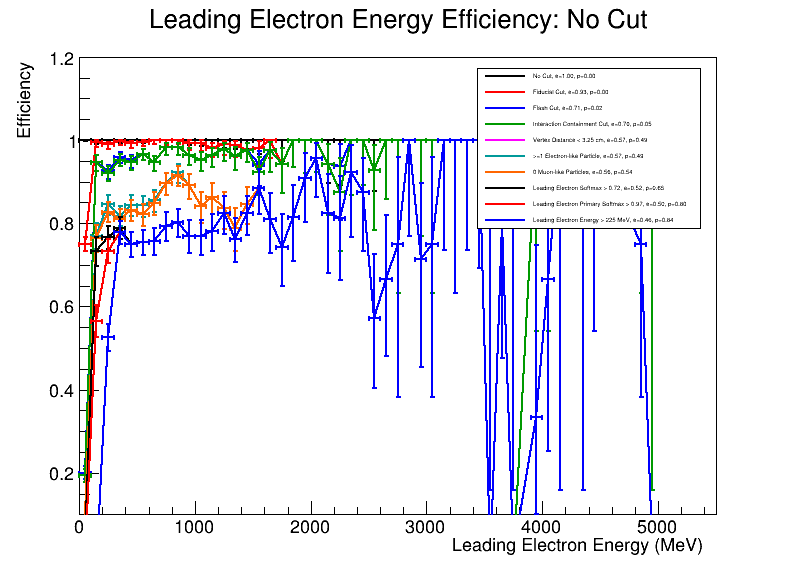

In [78]:
total_entries = ak.sum(fevt['event_nnu_e'].array())
hists = get_effHists('reco_leading_electron_energy', fall, selections, total=total_entries, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron Energy Efficiency", "Leading Electron Energy (MeV)", "Efficiency", range=(0.1, 1.2))
c.SetLogy(0)
c.Draw()
l.Draw()

In [149]:
hists = get_varHists('reco_leading_electron_energy', fall, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron Energy after Selections", "Reconstructed Leading Electron Energy [MeV]", "Entries", range=(1, 10e7))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (2041/2041)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 1.0000 (2041/2041)
Applying selection: Flash Cut
Efficiency after Flash Cut: 1.0000 (2041/2041)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 1.0000 (2041/2041)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 1.0000 (2041/2041)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 1.0000 (2041/2041)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.0000 (0/2041)


TypeError: none of the 2 overloaded methods succeeded. Full details:
  void TH1::FillN(int ntimes, const double* x, const double* w, int stride = 1) =>
    TypeError: could not convert argument 2 (could not convert argument to buffer or nullptr)
  void TH1::FillN(int, const double*, const double*, const double*, int) =>
    TypeError: takes at least 5 arguments (3 given)

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


In [ ]:
hists = get_varHists('true_neutrino_energy', fall, bins=50, xmin=0, xmax=5)
c, l = plot_hists(hists, selections, "True Neutrino Energy after Selections", "True Neutrino Energy [MeV]", "Entries", range=(1, 10e5))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Valid Flash Match
Efficiency after Valid Flash Match: 0.6904 (3118/4516)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6608 (2984/4516)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6116 (2762/4516)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5534 (2499/4516)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.5250 (2371/4516)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.5224 (2359/4516)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.4723 (2133/4516)


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


In [234]:
hists = get_varHists('reco_leading_electron_electron_softmax', fall, bins=50, xmin=0, xmax=1)
c, l = plot_hists(hists, selections, "Leading Electron Electron Softmax after Selections", "Leading Electron Electron Softmax", "Entries", range=(1, 10e5))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Valid Flash Match
Efficiency after Valid Flash Match: 0.6904 (3118/4516)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6608 (2984/4516)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6116 (2762/4516)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5534 (2499/4516)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.5250 (2371/4516)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.5224 (2359/4516)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.4723 (2133/4516)


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


In [235]:
hists = get_varHists('reco_leading_electron_photon_softmax', fall, bins=50, xmin=0, xmax=1)
c, l = plot_hists(hists, selections, "Leading Electron Photon Softmax after Selections", "Leading Electron Photon Softmax", "Entries", range=(1, 10e5))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Valid Flash Match
Efficiency after Valid Flash Match: 0.6904 (3118/4516)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6608 (2984/4516)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6116 (2762/4516)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5534 (2499/4516)
Applying selection: Leading Electron Primary Softmax > 0.97
Efficiency after Leading Electron Primary Softmax > 0.97: 0.5250 (2371/4516)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.5224 (2359/4516)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.4723 (2133/4516)


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


# Determine binning by plotting true vs reco energy/angle

In [23]:
fullSel = ak.ones_like(fall['reco_leading_electron_energy'].array(), dtype=bool)
for sel in selections:
    print(f"Applying selection: {sel.label}")
    # Use the apply_cut method instead of hardcoded == 1
    fullSel = fullSel & sel.apply_cut(fall[sel.name].array())

category = fall['true_category'].array()[fullSel]

reco_energy = fall['reco_leading_electron_energy'].array()[fullSel]
reco_energy = reco_energy[(category == 0)] 
true_energy = fall['true_leading_electron_energy'].array()[fullSel]
true_energy = true_energy[(category == 0)]

Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Flash Cut
Applying selection: Interaction Containment Cut
Applying selection: Vertex Distance < 3.25 cm
Applying selection: >=1 Electron-like Particle
Applying selection: 0 Muon-like Particles
Applying selection: Leading Electron Softmax > 0.72
Applying selection: Leading Electron Primary Softmax > 0.97
Applying selection: Leading Electron Energy > 225 MeV


Warning in <TROOT::Append>: Replacing existing TH1: h_reco_energy (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_true_energy (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_energy2d (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


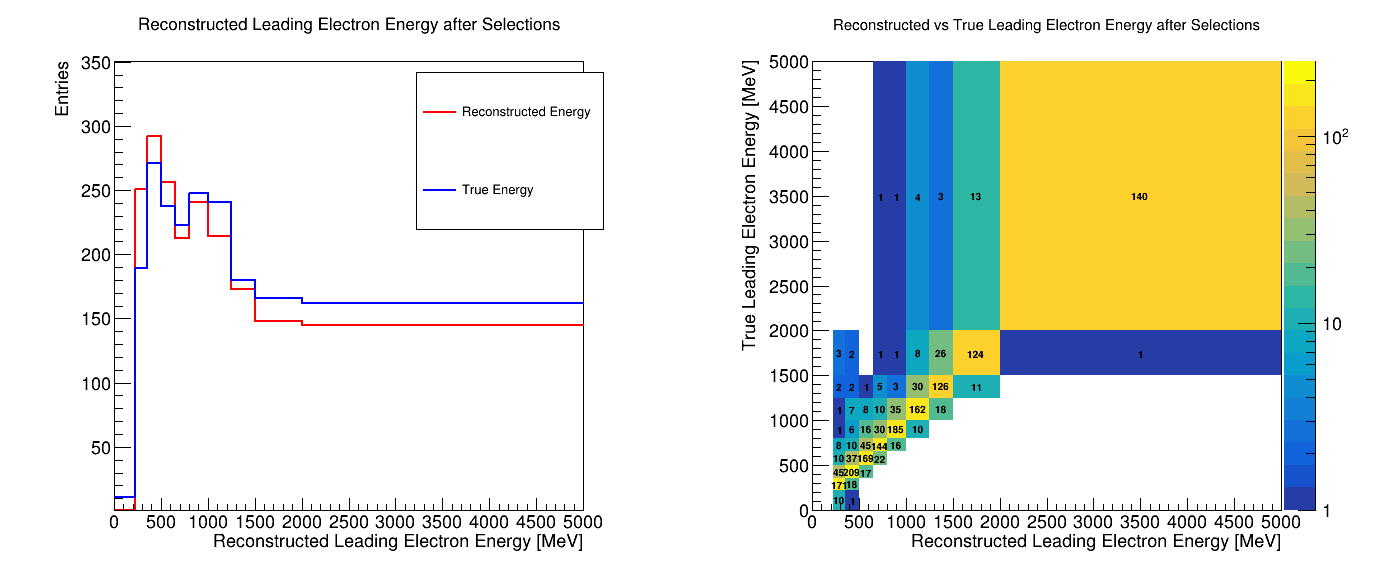

In [79]:
# bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

h_reco_energy = r.TH1F("h_reco_energy", "h_reco_energy", len(bins)-1, np.array(bins, dtype='d'))
h_true_energy = r.TH1F("h_true_energy", "h_true_energy", len(bins)-1, np.array(bins, dtype='d'))

h_energy2d = r.TH2F("h_energy2d", "h_energy2d", len(bins)-1, np.array(bins, dtype='d'), len(bins)-1, np.array(bins, dtype='d'))

h_reco_energy.FillN(len(reco_energy), arr.array('d', reco_energy), np.ones(len(reco_energy)))
h_true_energy.FillN(len(true_energy), arr.array('d', true_energy), np.ones(len(true_energy)))
h_energy2d.FillN(len(reco_energy), arr.array('d', reco_energy), arr.array('d', true_energy), np.ones(len(reco_energy)))

c1 = r.TCanvas("c1", "c1", 1400, 600)
c1.Divide(2, 1)

c1.cd(1)
h_reco_energy.SetLineColor(r.kRed)
h_reco_energy.SetLineWidth(2)
h_reco_energy.SetTitle("Reconstructed Leading Electron Energy after Selections; Reconstructed Leading Electron Energy [MeV]; Entries")
h_reco_energy.GetYaxis().SetRangeUser(1, max(h_reco_energy.GetMaximum(), h_true_energy.GetMaximum()) * 1.2)
h_reco_energy.Draw()
h_true_energy.SetLineColor(r.kBlue)
h_true_energy.SetLineWidth(2)
h_true_energy.SetTitle("True Leading Electron Energy after Selections; True Leading Electron Energy [MeV]; Entries")
h_true_energy.Draw("SAME")

l = r.TLegend(0.6, 0.6, 0.88, 0.88)
l.AddEntry(h_reco_energy, f"Reconstructed Energy", "l")
l.AddEntry(h_true_energy, f"True Energy", "l")
l.Draw()

r.gPad.SetRightMargin(0.15)
r.gPad.SetLeftMargin(0.15)

c1.cd(2)
h_energy2d.SetTitle("Reconstructed vs True Leading Electron Energy after Selections; Reconstructed Leading Electron Energy [MeV]; True Leading Electron Energy [MeV]")
h_energy2d.GetZaxis().SetRangeUser(1, h_energy2d.GetMaximum() * 1.2)
h_energy2d.Draw("COLZ TEXT")
r.gPad.SetLogz()
r.gPad.SetLeftMargin(0.15)
r.gPad.SetRightMargin(0.15)

c1.Draw()

%jsroot off

In [82]:
a_reco = np.cos(fall['reco_ele_beam_open_angle'].array())
a_true = np.cos(fall['true_ele_beam_open_angle'].array())

fullSel = ak.ones_like(a_true, dtype=bool)
for sel in selections:
    print(f"Applying selection: {sel.label}")
    # Use the apply_cut method instead of hardcoded == 1
    fullSel = fullSel & sel.apply_cut(fall[sel.name].array())

category = fall['true_category'].array()[fullSel]
    
reco_angle = a_reco[fullSel]
reco_angle = reco_angle[(category == 0)]
true_angle = a_true[fullSel]
true_angle = true_angle[(category == 0)]

Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Flash Cut
Applying selection: Interaction Containment Cut
Applying selection: Vertex Distance < 3.25 cm
Applying selection: >=1 Electron-like Particle
Applying selection: 0 Muon-like Particles
Applying selection: Leading Electron Softmax > 0.72
Applying selection: Leading Electron Primary Softmax > 0.97
Applying selection: Leading Electron Energy > 225 MeV


Warning in <TROOT::Append>: Replacing existing TH1: h_reco_angle (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_true_angle (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_angle2d (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


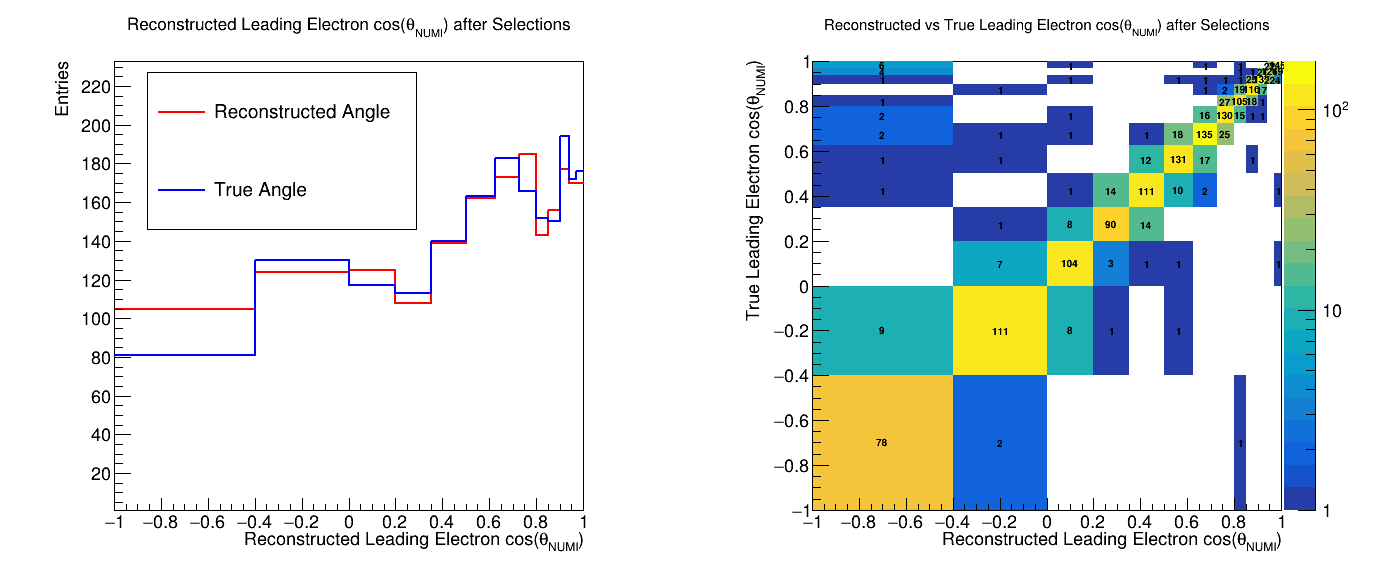

In [83]:
bins = [-1.0, -0.4, 0.0, 0.2, 0.35, 0.5, 0.625, 0.725, 0.8, 0.85, 0.9, 0.94, 0.97, 1.0]

h_reco_angle = r.TH1F("h_reco_angle", "h_reco_angle", len(bins)-1, np.array(bins, dtype='d'))
h_true_angle = r.TH1F("h_true_angle", "h_true_angle", len(bins)-1, np.array(bins, dtype='d'))

h_angle2d = r.TH2F("h_angle2d", "h_angle2d", len(bins)-1, np.array(bins, dtype='d'), len(bins)-1, np.array(bins, dtype='d'))

h_reco_angle.FillN(len(reco_angle), arr.array('d', reco_angle), np.ones(len(reco_angle)))
h_true_angle.FillN(len(true_angle), arr.array('d', true_angle), np.ones(len(true_angle)))
h_angle2d.FillN(len(reco_angle), arr.array('d', reco_angle), arr.array('d', true_angle), np.ones(len(reco_angle)))

c1 = r.TCanvas("c1", "c1", 1400, 600)
c1.Divide(2, 1)

c1.cd(1)
h_reco_angle.SetLineColor(r.kRed)
h_reco_angle.SetLineWidth(2)
h_reco_angle.SetTitle("Reconstructed Leading Electron cos(#theta_{NUMI}) after Selections; Reconstructed Leading Electron cos(#theta_{NUMI}); Entries")
h_reco_angle.GetYaxis().SetRangeUser(1, max(h_reco_angle.GetMaximum(), h_true_angle.GetMaximum()) * 1.2)
h_reco_angle.Draw()
h_true_angle.SetLineColor(r.kBlue)
h_true_angle.SetLineWidth(2)
h_true_angle.SetTitle("True Leading Electron cos(#theta_{NUMI}) after Selections; True Leading Electron cos(#theta_{NUMI}); Entries")
h_true_angle.Draw("SAME")

l = r.TLegend(0.2, 0.6, 0.6, 0.88)
l.AddEntry(h_reco_angle, f"Reconstructed Angle", "l")
l.AddEntry(h_true_angle, f"True Angle", "l")
l.Draw()

r.gPad.SetRightMargin(0.15)
r.gPad.SetLeftMargin(0.15)

c1.cd(2)
h_angle2d.SetTitle("Reconstructed vs True Leading Electron cos(#theta_{NUMI}) after Selections; Reconstructed Leading Electron cos(#theta_{NUMI}); True Leading Electron cos(#theta_{NUMI})")
h_angle2d.GetZaxis().SetRangeUser(1, h_angle2d.GetMaximum() * 1.2)
h_angle2d.Draw("COLZ TEXT")
r.gPad.SetLogz()
r.gPad.SetLeftMargin(0.15)
r.gPad.SetRightMargin(0.15)

c1.Draw()

### Draw the initial and final counts in bins to check efficiency calculation

In [55]:
fullSel = ak.ones_like(fall['reco_leading_electron_energy'].array(), dtype=bool)
for sel in selections:
    print(f"Applying selection: {sel.label}")
    # Use the apply_cut method instead of hardcoded == 1
    fullSel = fullSel & sel.apply_cut(fall[sel.name].array())

signal_nocut = fall['true_category'].array()[selections[0].apply_cut(fall[selections[0].name].array())] == 0
signal = fall['true_category'].array()[fullSel] == 0

reco_energy_nocut = fall['reco_leading_electron_energy'].array()[selections[0].apply_cut(fall[selections[0].name].array())]
reco_energy_nocut = reco_energy_nocut[signal_nocut]

reco_energy = fall['reco_leading_electron_energy'].array()[fullSel]
reco_energy = reco_energy[signal]   

bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

h_reco_energy_nocut = r.TH1F("h_reco_energy_nocut", "h_reco_energy_nocut", len(bins)-1, np.array(bins, dtype='d'))
h_reco_energy = r.TH1F("h_reco_energy", "h_reco_energy", len(bins)-1, np.array(bins, dtype='d'))

h_reco_energy_nocut.FillN(len(reco_energy_nocut), arr.array('d', reco_energy_nocut), np.ones(len(reco_energy_nocut)))
h_reco_energy.FillN(len(reco_energy), arr.array('d', reco_energy), np.ones(len(reco_energy)))

c1 = r.TCanvas("c1", "c1", 800, 600)
h_reco_energy_nocut.SetLineColor(r.kRed)
h_reco_energy_nocut.SetLineWidth(2)
h_reco_energy_nocut.SetTitle("Reconstructed Leading Electron Energy; Reconstructed Leading Electron Energy [MeV]; Entries")
h_reco_energy_nocut.GetYaxis().SetRangeUser(1, max(h_reco_energy_nocut.GetMaximum(), h_reco_energy.GetMaximum()) * 1.2)
h_reco_energy.SetLineColor(r.kBlue)
h_reco_energy.SetLineWidth(2)
h_reco_energy.SetTitle("Reconstructed Leading Electron Energy after Selections; Reconstructed Leading Electron Energy [MeV]; Entries")

Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Flash Cut
Applying selection: Interaction Containment Cut
Applying selection: Vertex Distance < 3.25 cm
Applying selection: >=1 Electron-like Particle
Applying selection: 0 Muon-like Particles
Applying selection: Leading Electron Softmax > 0.72
Applying selection: Leading Electron Primary Softmax > 0.97
Applying selection: Leading Electron Energy > 225 MeV


Warning in <TROOT::Append>: Replacing existing TH1: h_reco_energy_nocut (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco_energy (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


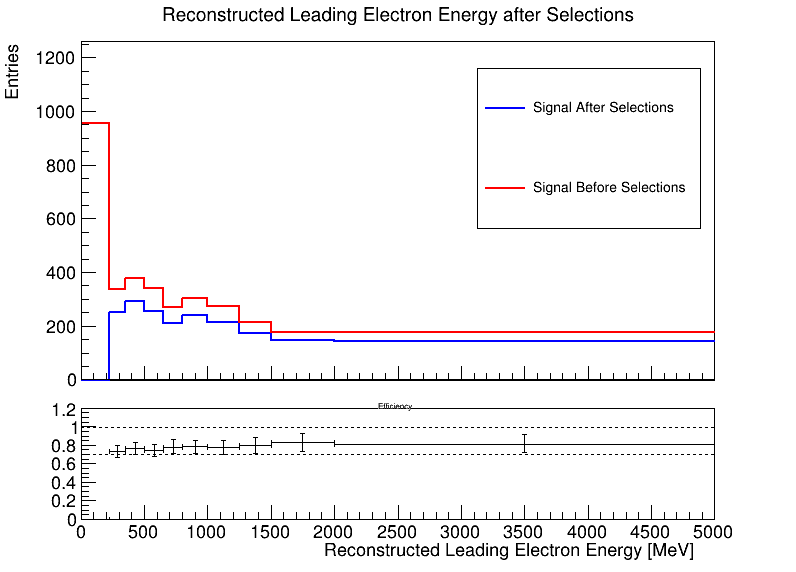

In [56]:
%jsroot off

h_ratio = r.TRatioPlot(h_reco_energy, h_reco_energy_nocut, "pois")
h_ratio.SetH1DrawOpt("hist")
h_ratio.SetH2DrawOpt("hist")

l = r.TLegend(0.6, 0.6, 0.88, 0.88)
l.AddEntry(h_reco_energy, f"Signal After Selections", "l")
l.AddEntry(h_reco_energy_nocut, f"Signal Before Selections", "l")

h_ratio.Draw()

l.Draw()

# h_ratio.GetUpperPad().SetLogy(0)
h_ratio.GetUpperRefObject().SetMinimum(0.)
h_ratio.GetUpperRefObject().SetMaximum(h_reco_energy_nocut.GetMaximum() * 1.1)
h_ratio.GetLowerRefGraph().SetMinimum(0.)
h_ratio.GetLowerRefGraph().SetMaximum(1.2)
h_ratio.GetLowerRefGraph().SetTitle("Efficiency")
# h_ratio.GetLowerRefGraph().GetYaxis().SetTitleSize(0.1)
# h_ratio.GetLowerRefGraph().GetYaxis().SetTitleOffset(0.5)
# h_ratio.GetLowerRefGraph().GetYaxis().SetLabelSize(0.08)
h_ratio.GetLowerRefGraph().SetLineColor(r.kBlack)
# h_ratio.GetLowerPad().SetLogy(0)
c1.Draw()
c1.SetLogy(1)

# Make Plots with spineplot

### efficiency plots are too memory intensive to run here, run on build node and then fix plots here

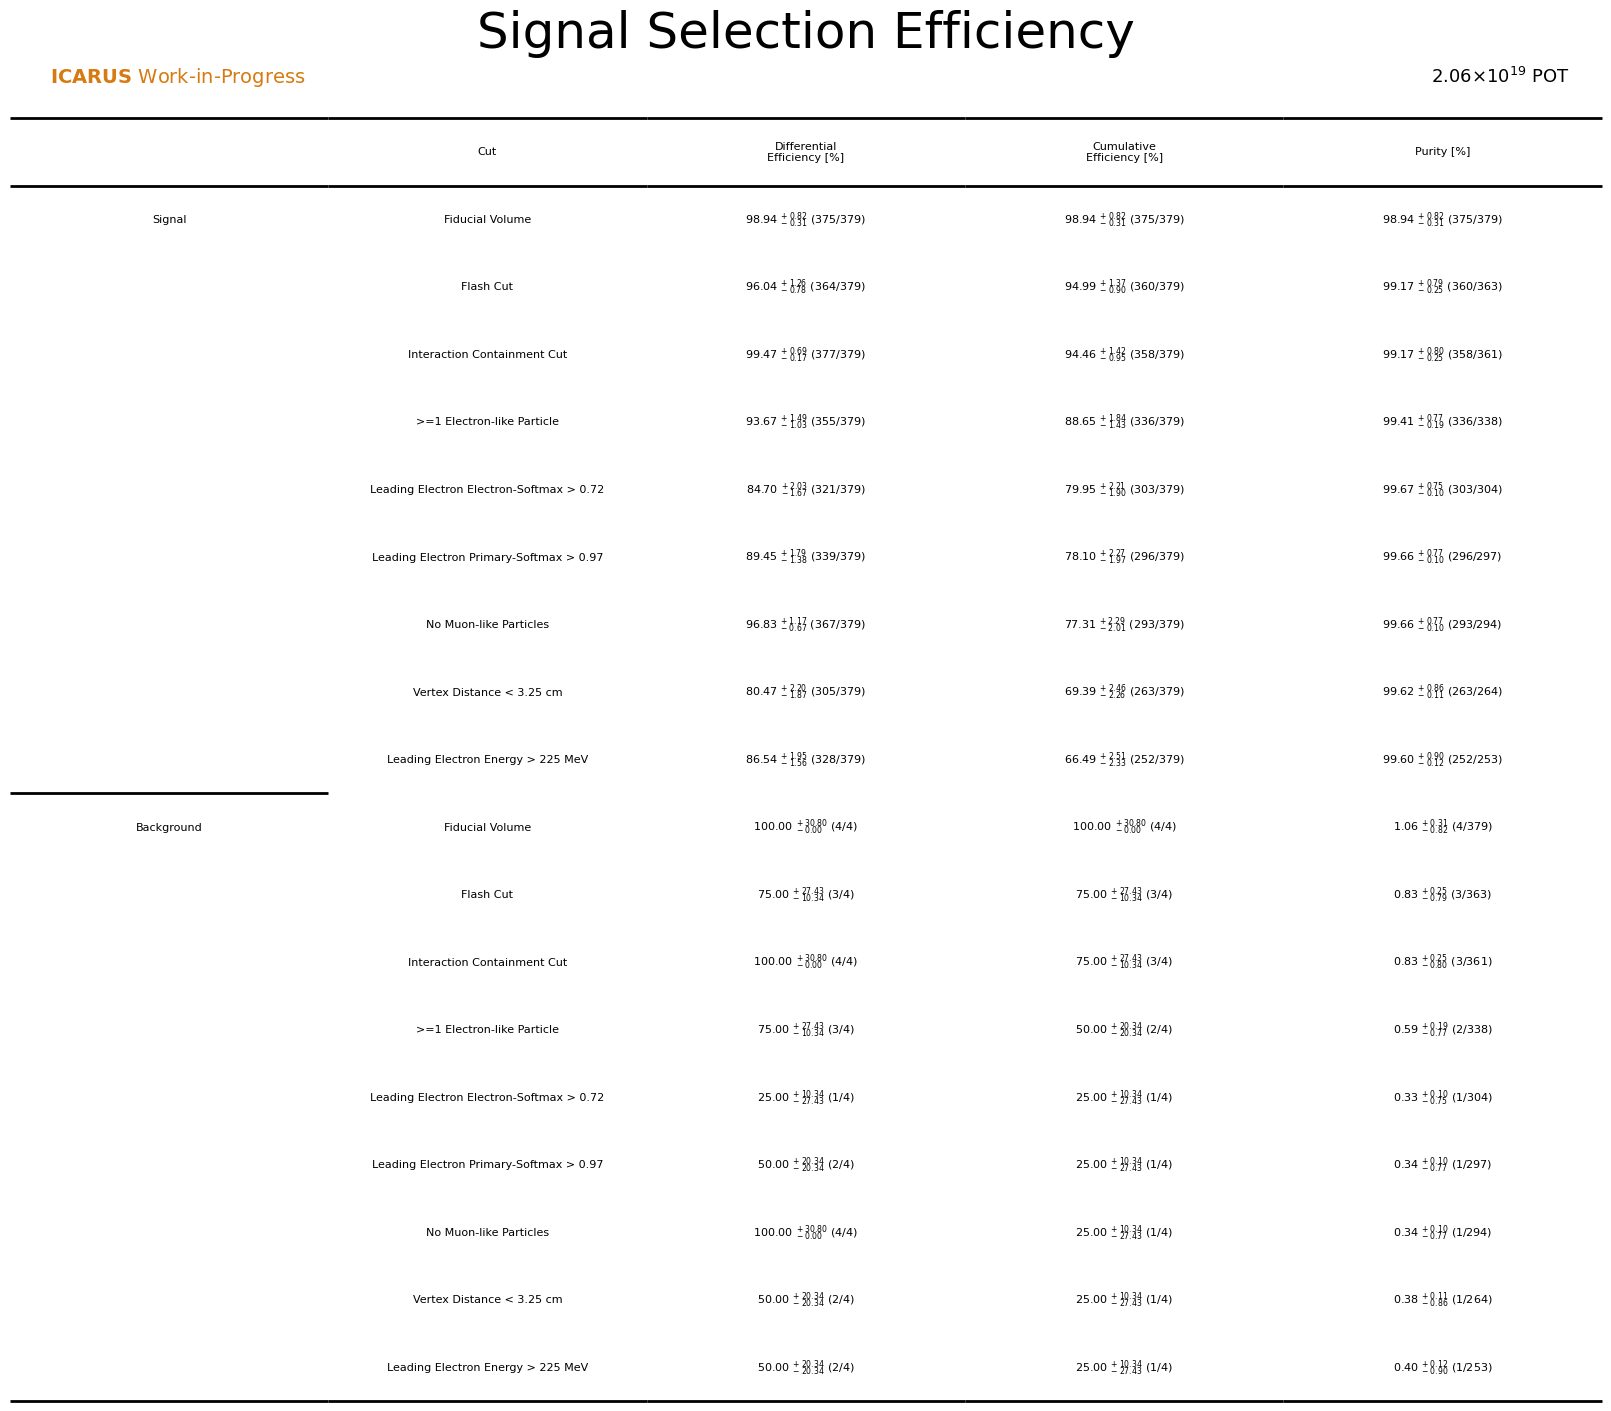

In [56]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/selection_efficiency_table.pkl', 'rb') as f:
    eff = pickle.load(f)
    eff.set_size_inches(16, 14)
    ax = eff.axes[0]
    table = ax.tables[0]
    table.auto_set_font_size(False)
    table.set_fontsize(8)

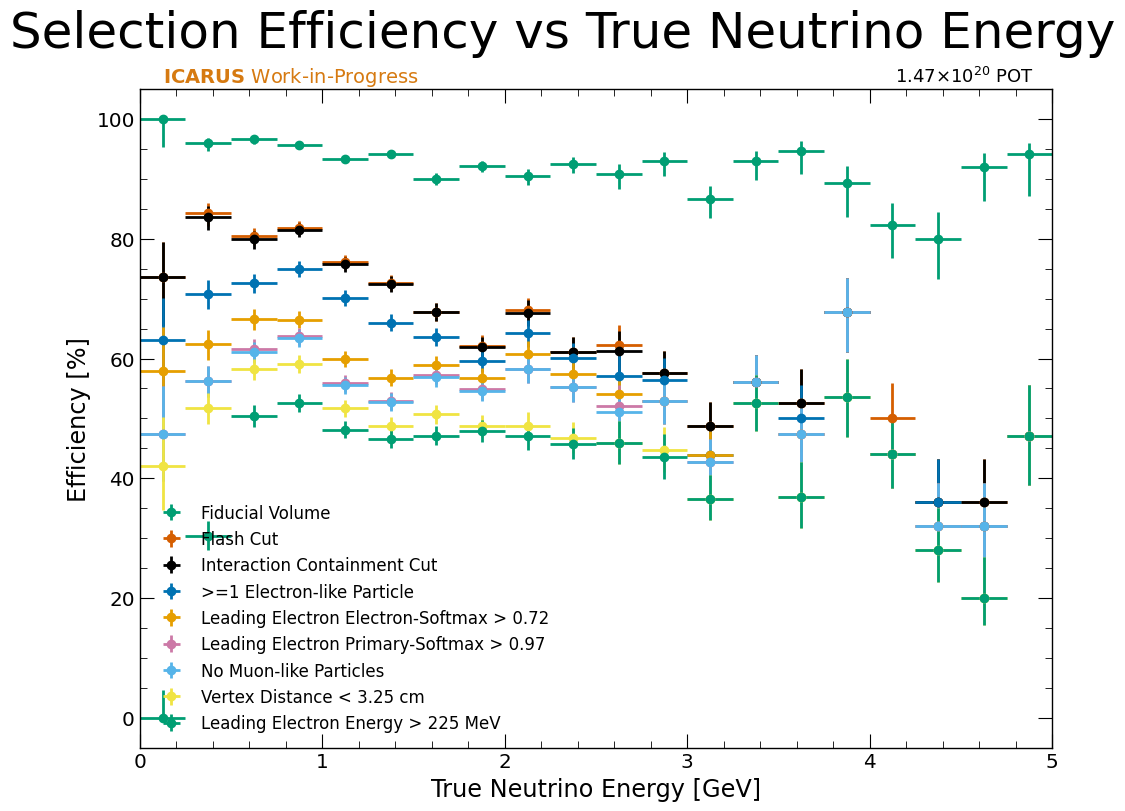

In [28]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_energy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    # ax = eff_nuE.axes[0]
    # ax.set_yscale('log')
    # ax.set_ylim(1e-3, 100)

    # ymin, ymax = ax.get_ylim()
    # if ymin <= 0:
    #     pos_vals = []
    #     for line in ax.lines:
    #         y = np.asarray(line.get_ydata())
    #         pos_vals.extend(y[y > 0].tolist())
    #     if len(pos_vals) > 0:
    #         ymin_new = min(pos_vals)
    #     else:
    #         ymin_new = 1e-5
    #     ax.set_ylim(ymin_new * 0.5, max(ymax, ymin_new * 20))

    # ax.grid(True, which='both', ls='--', alpha=0.6)
    # plt.show()

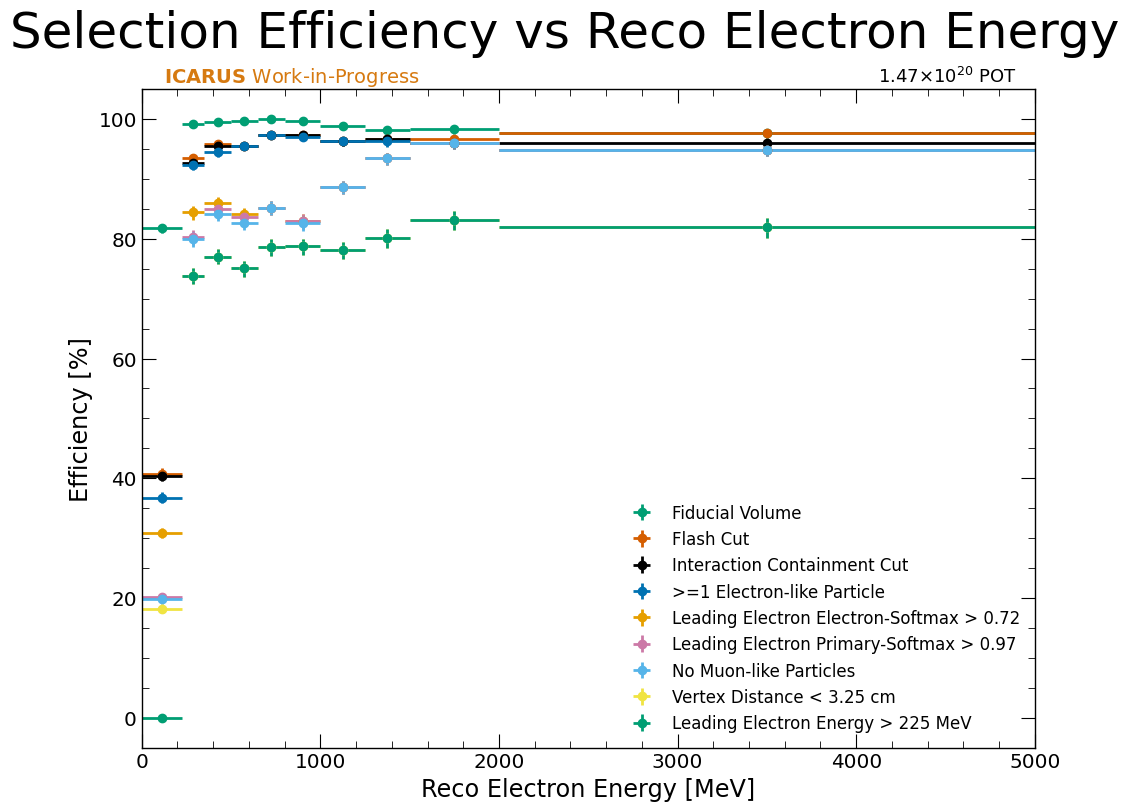

In [29]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_electronEnergy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

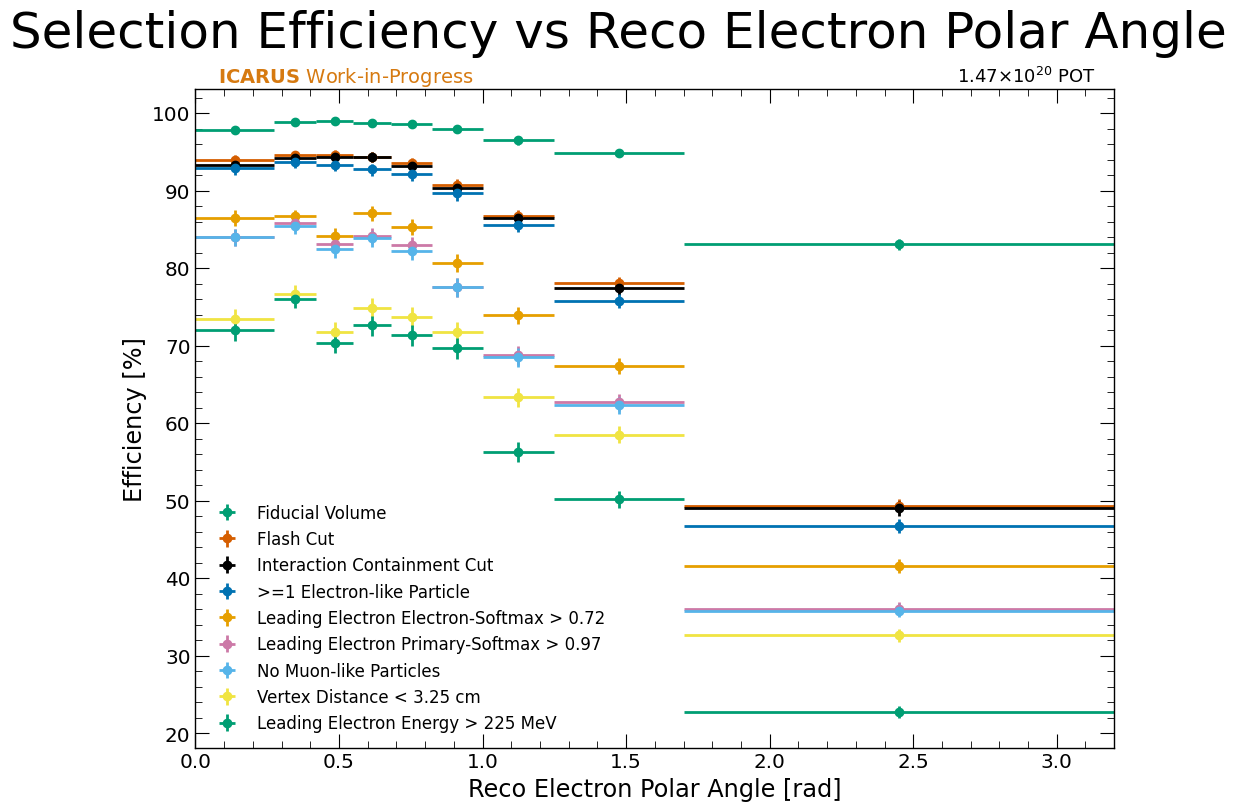

In [30]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_electronAngle.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

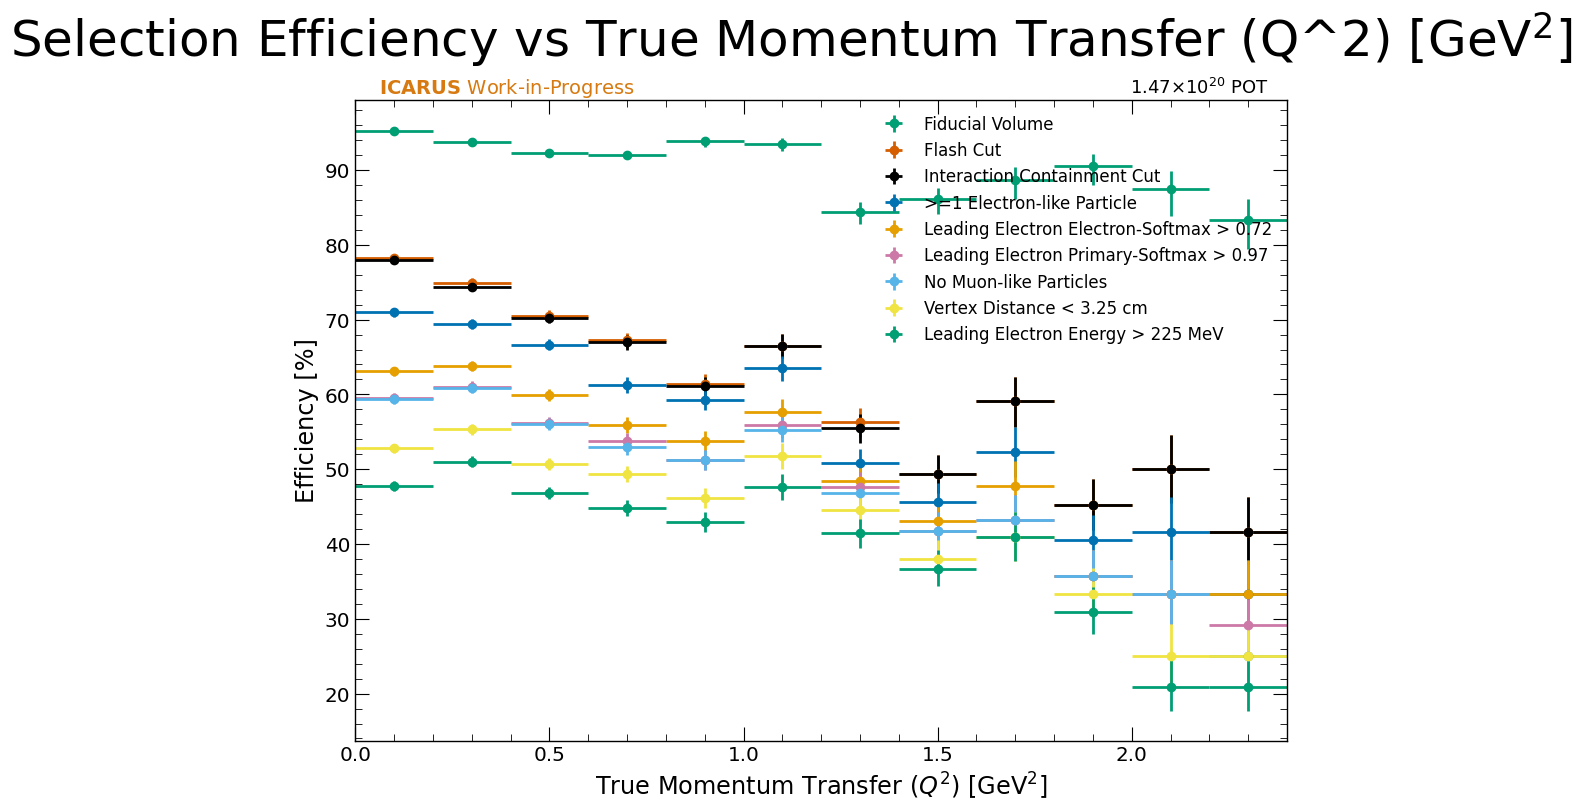

In [31]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_trueMomentumTransfer.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

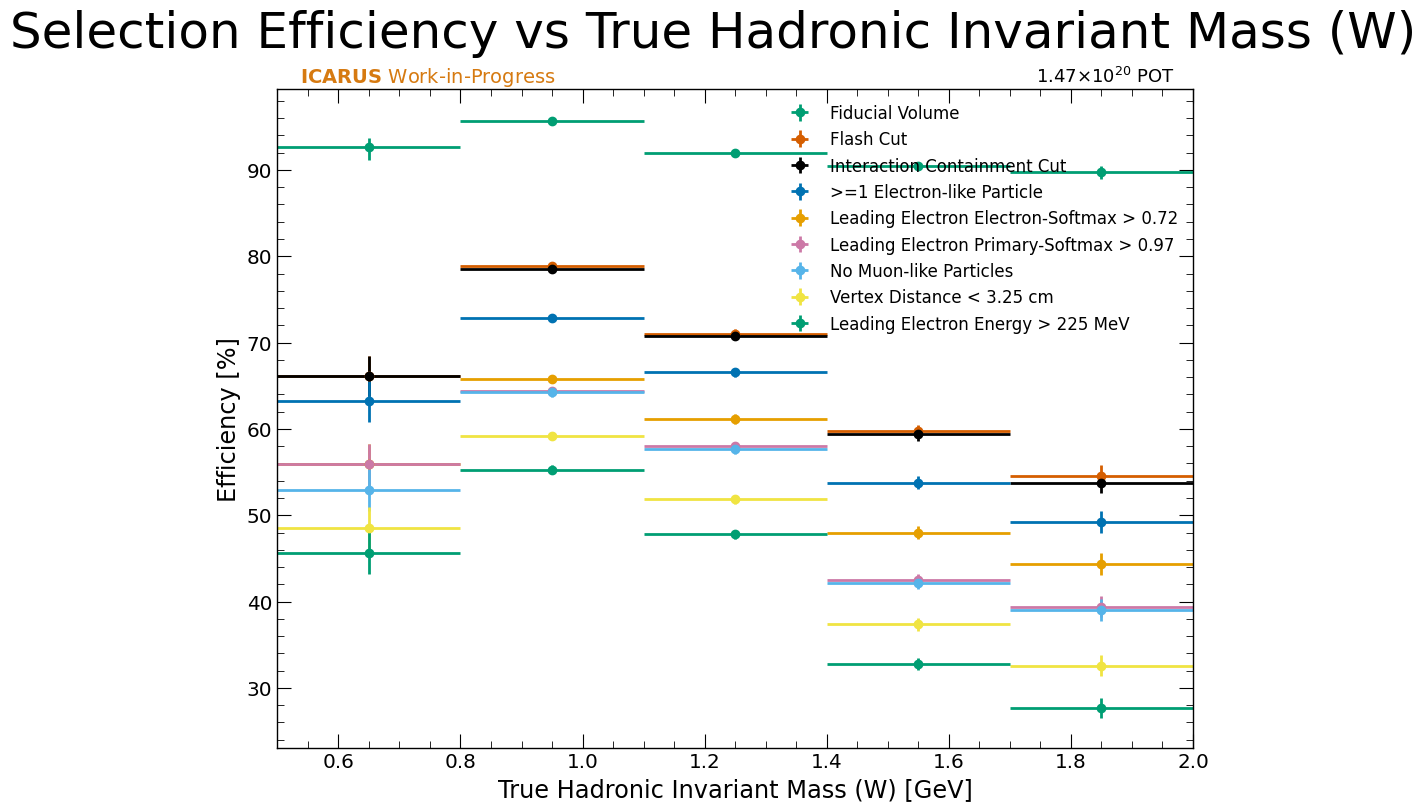

In [32]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_vs_trueInvMass.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

In [84]:
# extract histogram data from h_nuE (robust to bars/lines/paches)
def _extract_hist(ax):
    # 1) bar containers (matplotlib.container.BarContainer)
    if len(ax.containers) > 0:
        all_heights = None
        base_lefts = None
        base_widths = None
        for cont in ax.containers:
            lefts = [rect.get_x() for rect in cont]
            widths = [rect.get_width() for rect in cont]
            heights = np.array([rect.get_height() for rect in cont], dtype=float)

            if all_heights is None:
                all_heights = heights
                base_lefts = lefts
                base_widths = widths
            else:
                # align lengths if containers differ (pad with zeros)
                if len(heights) < len(all_heights):
                    heights = np.pad(heights, (0, len(all_heights) - len(heights)), constant_values=0.0)
                elif len(heights) > len(all_heights):
                    all_heights = np.pad(all_heights, (0, len(heights) - len(all_heights)), constant_values=0.0)
                all_heights += heights

        if base_lefts is None:
            raise RuntimeError("No bar containers found")
        edges = np.array(base_lefts + [base_lefts[-1] + base_widths[-1]])
        return edges, all_heights
    # 2) Line2D (step or line)
    lines = ax.get_lines()
    if len(lines) > 0:
        line = lines[0]
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())
        return x, y
    # 3) individual patches
    patches = getattr(ax, "patches", [])
    if patches:
        lefts = [p.get_x() for p in patches]
        widths = [p.get_width() for p in patches]
        heights = [p.get_height() for p in patches]
        edges = np.array(lefts + [lefts[-1] + widths[-1]])
        return edges, np.array(heights)
    raise RuntimeError("No histogram found on the provided Axes")

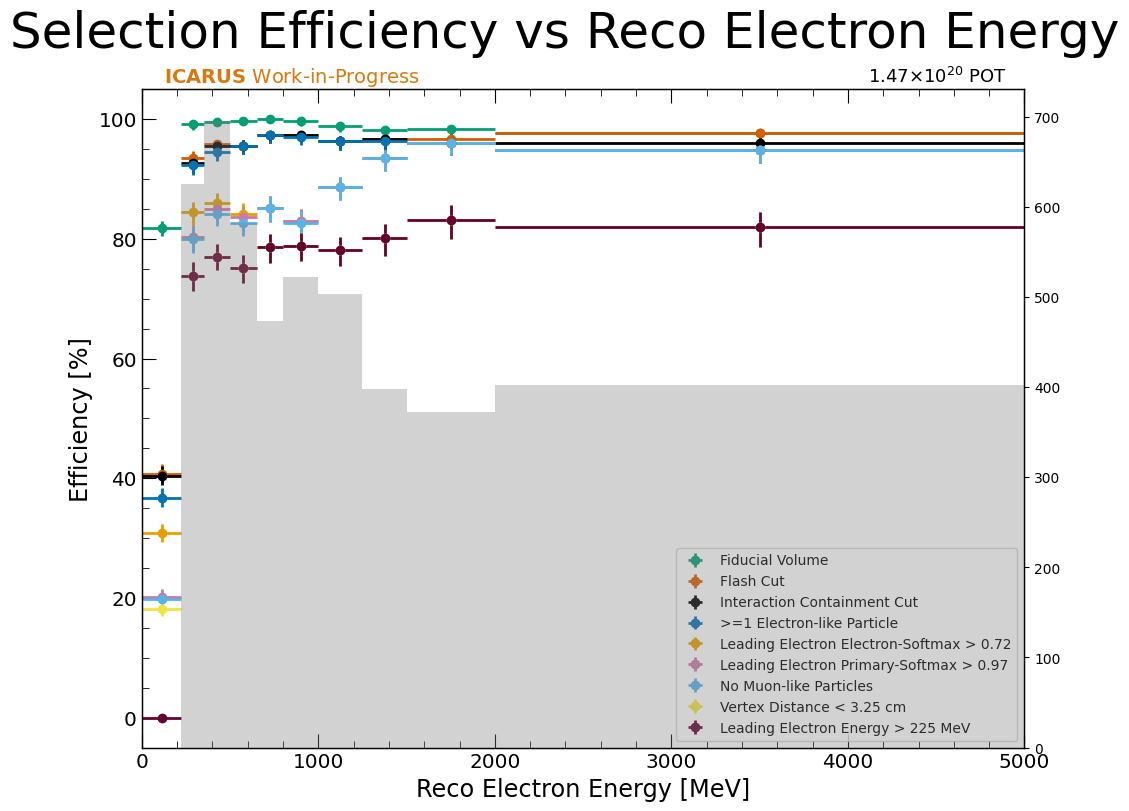

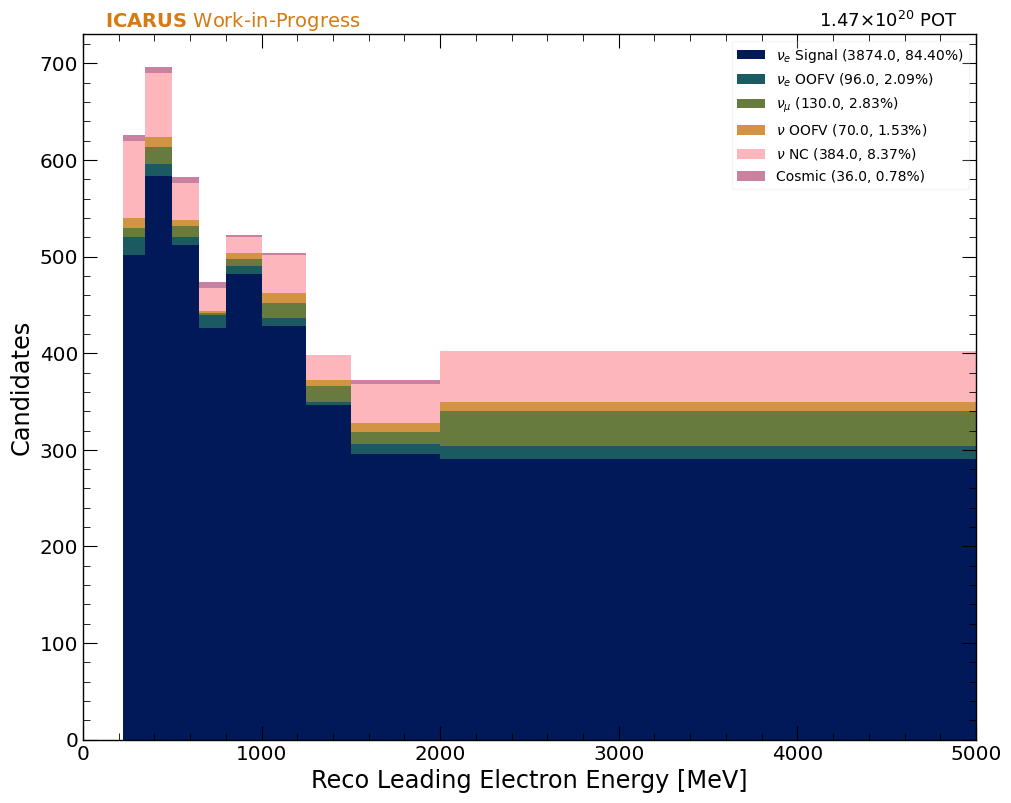

In [85]:
with open('/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_electronEnergy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)

with open('/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_reco_leading_electron_energy.pkl', 'rb') as f:
    h_nuE = pickle.load(f)
    h_nuE.set_size_inches(10, 8)

    ax_hist = h_nuE.axes[0]
    ax_eff = eff_nuE.axes[0]

    edges_or_x, counts_or_y = _extract_hist(ax_hist)

    # plot histogram onto eff_nuE using a twin y-axis (keeps efficiency scale intact)
    ax2 = ax_eff.twinx()
    if len(edges_or_x) == len(counts_or_y) + 1:
        # edges + counts
        edges = edges_or_x
        counts = counts_or_y
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths = edges[1:] - edges[:-1]
        ax2.bar(centers, counts, width=widths, alpha=0.35, color='gray', label='Counts (from h_nuE)', align='center')
    else:
        # line-style data
        x = edges_or_x
        y = counts_or_y
        ax2.step(x, y, where='mid', color='gray', alpha=0.8, label='Counts (from h_nuE)')

    # ax2.set_ylabel('Counts')
    # ax2.legend(loc='upper right')
    ax_eff.legend(loc='lower right')

    # draw/update the figure
    eff_nuE.canvas.draw()
    # plt.show()

## Overlay Efficiency and Histogram Plots

In [118]:
import pickle
import copy

def overlay_hist_on_efficiency(eff_path, hist_path,
                               alpha=0.35,
                               figsize=(12, 6),
                               hist_legend_loc=None,
                               hist_legend_anchor=(0.0, 1.0),
                               eff_legend_loc='lower right',
                               eff_legend_anchor=(1.0, 0.0)):
    with open(eff_path, 'rb') as f:
        eff_fig = pickle.load(f)
    with open(hist_path, 'rb') as f:
        hist_fig = pickle.load(f)

    ax_eff  = eff_fig.axes[0]
    ax_hist = hist_fig.axes[0]

    # twin y-axis on the efficiency figure (keeps efficiency scale intact)
    ax2 = ax_eff.twinx()
    ax2.set_ylabel('Counts')
    all_ymax = []

    # --- option 1: stacked bar containers (preserves per-category colours) ---
    if len(ax_hist.containers) > 0:
        bottom = None
        for cont in ax_hist.containers:
            lefts   = np.array([rect.get_x()     for rect in cont])
            widths  = np.array([rect.get_width()  for rect in cont])
            heights = np.array([rect.get_height() for rect in cont], dtype=float)
            color   = cont.patches[0].get_facecolor()
            # label lives on the first patch, not the container itself
            patch_label = cont.patches[0].get_label()
            label = patch_label if patch_label and not patch_label.startswith('_') else None
            centers = lefts + widths / 2
            ax2.bar(centers, heights, width=widths, bottom=bottom,
                    alpha=alpha, color=color, align='center', label=label)
            bottom = heights if bottom is None else bottom + heights
        if bottom is not None:
            all_ymax.append(float(np.nanmax(bottom)))

    # --- option 2: Line2D (step or line histogram) ---
    elif len(ax_hist.get_lines()) > 0:
        for line in ax_hist.get_lines():
            ydata = line.get_ydata()
            ax2.step(line.get_xdata(), ydata, where='mid',
                     color=line.get_color(), alpha=alpha,
                     linewidth=line.get_linewidth(), label=line.get_label())
            all_ymax.append(float(np.nanmax(ydata)))

    # --- option 3: individual patches (e.g. stairs / fill_between) ---
    elif len(ax_hist.patches) > 0:
        from matplotlib.patches import StepPatch
        step_patches = [p for p in ax_hist.patches if isinstance(p, StepPatch)]
        rect_patches = [p for p in ax_hist.patches if not isinstance(p, StepPatch)]

        if step_patches:
            # redraw StepPatch objects via stairs() to avoid coordinate-transform issues
            # facecolor alpha=0 means unfilled outlines — colour lives entirely in edgecolor
            for patch in step_patches:
                data   = patch.get_data()
                values = data.values
                edges  = data.edges
                ec   = np.array(patch.get_edgecolor()).ravel()
                fc   = np.array(patch.get_facecolor()).ravel()
                # use edgecolor RGB as the line colour; inherit fill only if fc alpha > 0
                edgecolor = ec[:3]
                filled    = fc[3] > 0
                facecolor = fc[:3] if filled else 'none'
                patch_label = patch.get_label()
                label = patch_label if patch_label and not patch_label.startswith('_') else None
                ax2.stairs(values, edges,
                           color=edgecolor,
                           fill=filled, facecolor=facecolor,
                           alpha=alpha, label=label)
                all_ymax.append(float(np.nanmax(values)))
        else:
            for patch in rect_patches:
                p2 = copy.copy(patch)
                p2.figure = None
                p2.axes   = None
                p2.set_alpha(alpha)
                ax2.add_patch(p2)
                if hasattr(patch, 'get_height'):
                    all_ymax.append(patch.get_height())

    else:
        raise RuntimeError("No histogram data found on the provided axes")

    # set hist y-axis to 1.2x the maximum value across all drawn elements
    if all_ymax:
        ax2.set_ylim(0, max(all_ymax) * 1.2)

    # legends
    ax_eff.legend(loc=eff_legend_loc, bbox_to_anchor=eff_legend_anchor,
                  fontsize=9, framealpha=0.7)
    hist_handles, hist_labels = ax2.get_legend_handles_labels()
    if hist_handles and hist_legend_loc is not None:
        ax2.legend(handles=hist_handles, labels=hist_labels,
                   loc=hist_legend_loc, bbox_to_anchor=hist_legend_anchor,
                   fontsize=9, framealpha=0.7)

    eff_fig.set_size_inches(figsize)
    eff_fig.canvas.draw()
    plt.close(hist_fig)
    return eff_fig

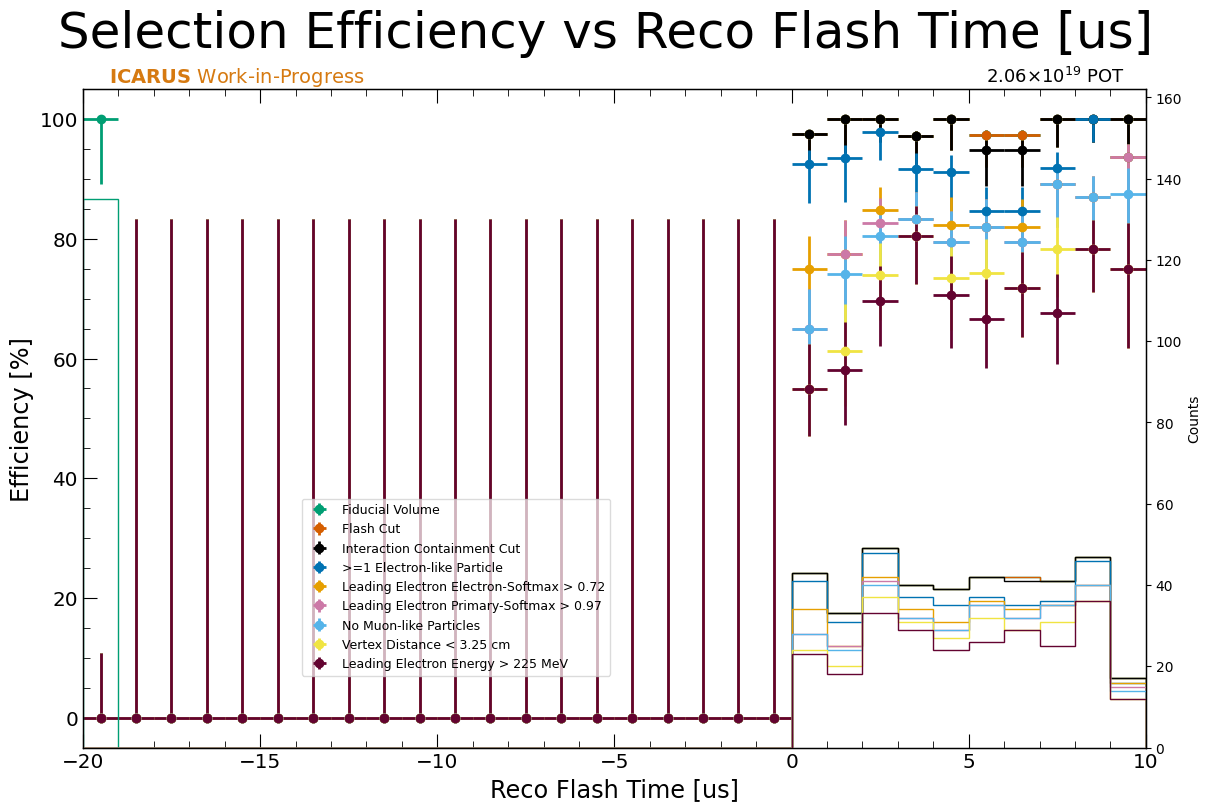


tab completion not implemented for this context


In [119]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_interactionFlashTime/efficiency_vs_recoFlashTime.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_interactionFlashTime/plot_reco_flash_time_mod.pkl',
    alpha               = 1.0,
    figsize             = (12, 8),
    hist_legend_loc     = None,
    hist_legend_anchor  = (0.2, 0.7),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.2, 0.1))
plt.show(fig)

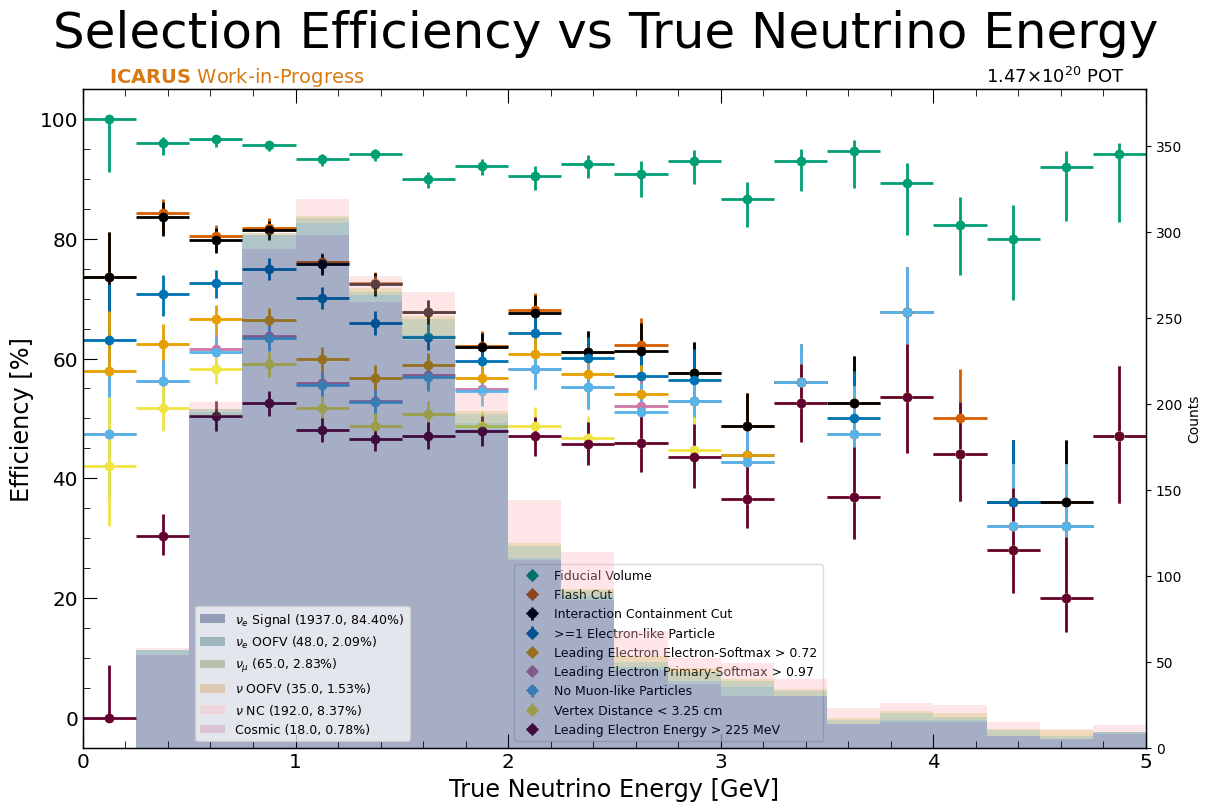

In [120]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_energy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_neutrino_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.1, 0.0),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.4, 0.0)
)
plt.show(fig)

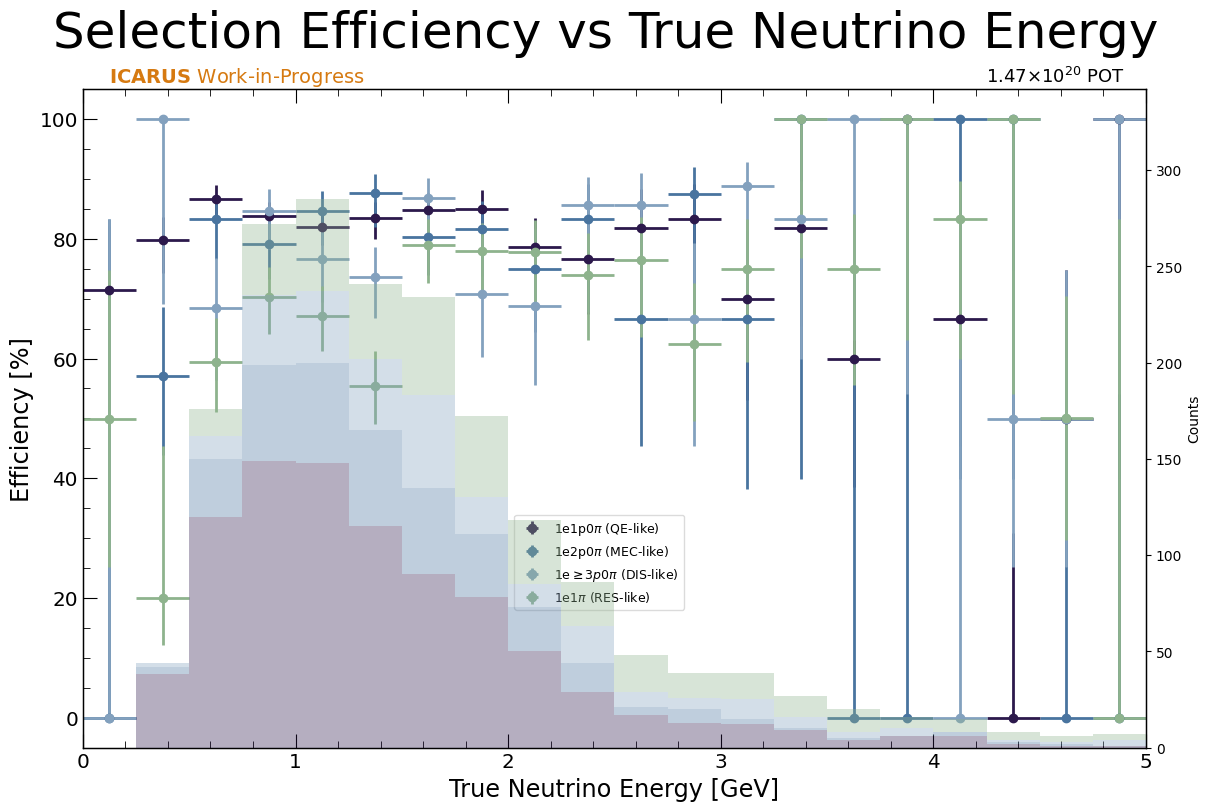

In [122]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_interaction/efficiency_vs_energy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_neutrino_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc=None,
    hist_legend_anchor  = (0.1, 0.0),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.4, 0.2)
)
plt.show(fig)

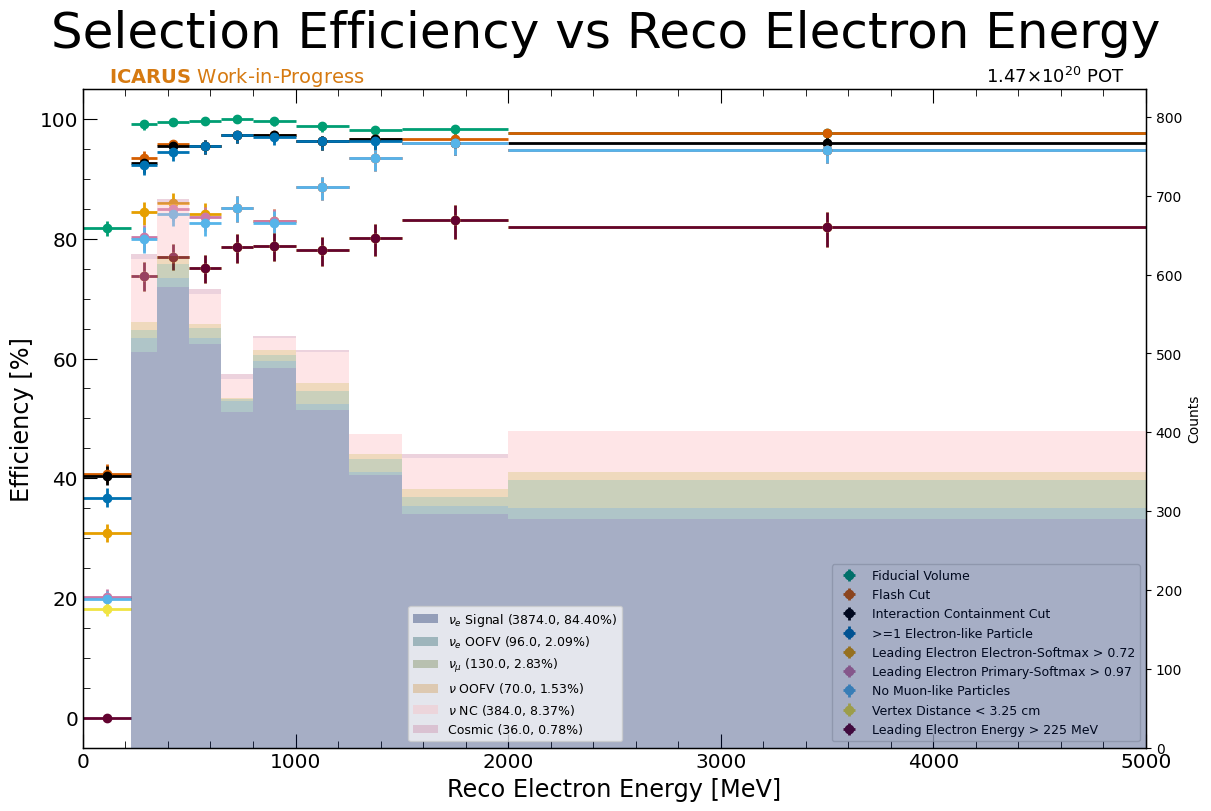

In [112]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_electronEnergy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_reco_leading_electron_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.3, 0.0),
    eff_legend_loc      = 'lower right',
    eff_legend_anchor   = (1.0, 0.0)
)
plt.show(fig)

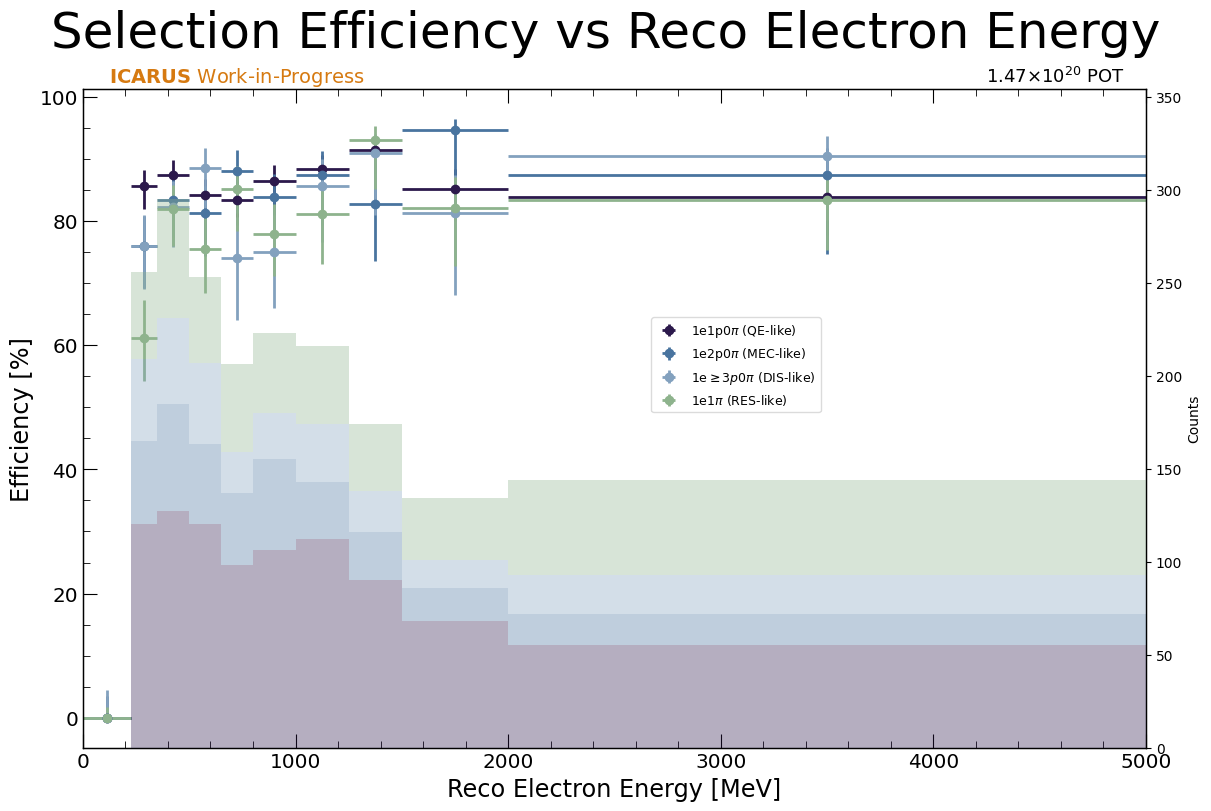

In [123]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_interaction/efficiency_vs_electronEnergy.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_reco_leading_electron_energy.pkl',
    alpha=0.35, figsize=(12, 8), 
    hist_legend_loc=None,
    hist_legend_anchor  = (0.3, 0.5),
    eff_legend_loc      = 'lower right',
    eff_legend_anchor   = (0.7, 0.5)
)
plt.show(fig)

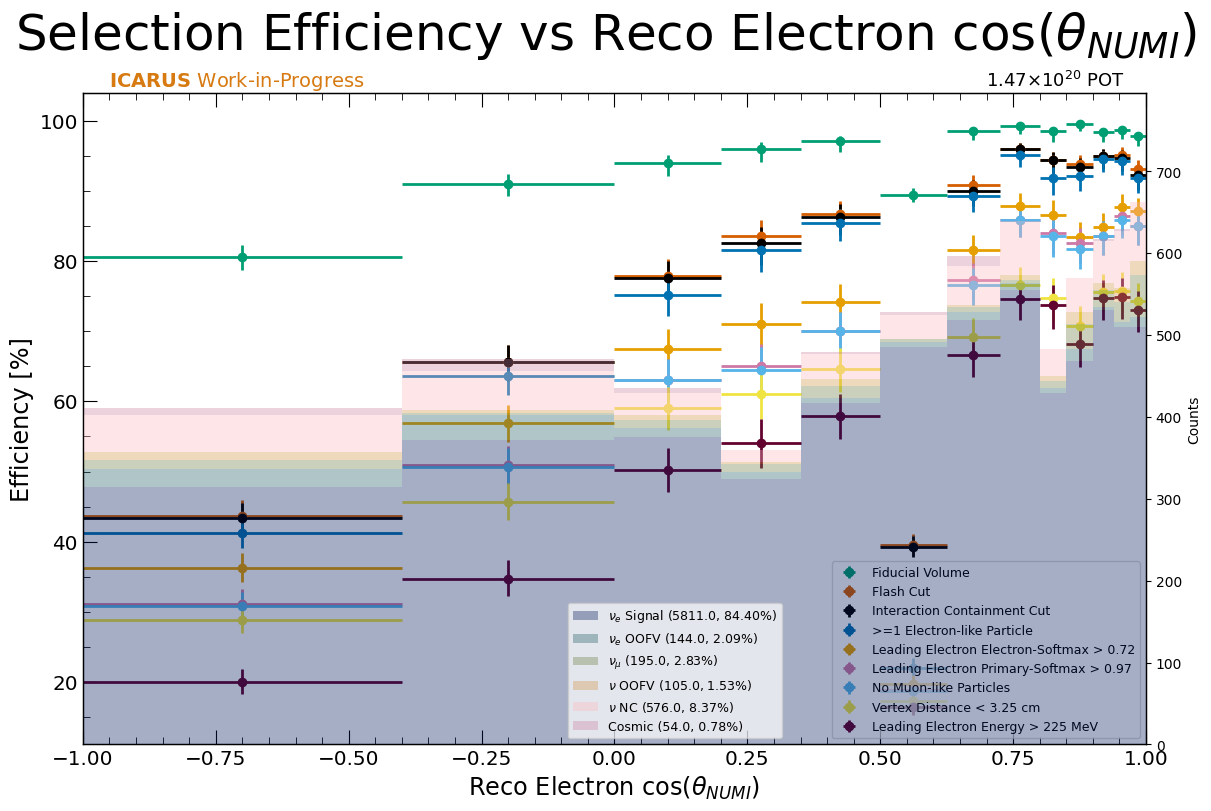

In [127]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_electronAngle.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_reco_ele_beam_cosTheta.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.45, 0.0),
    eff_legend_loc      = 'lower right',
    eff_legend_anchor   = (1.0, 0.0))
plt.show(fig)

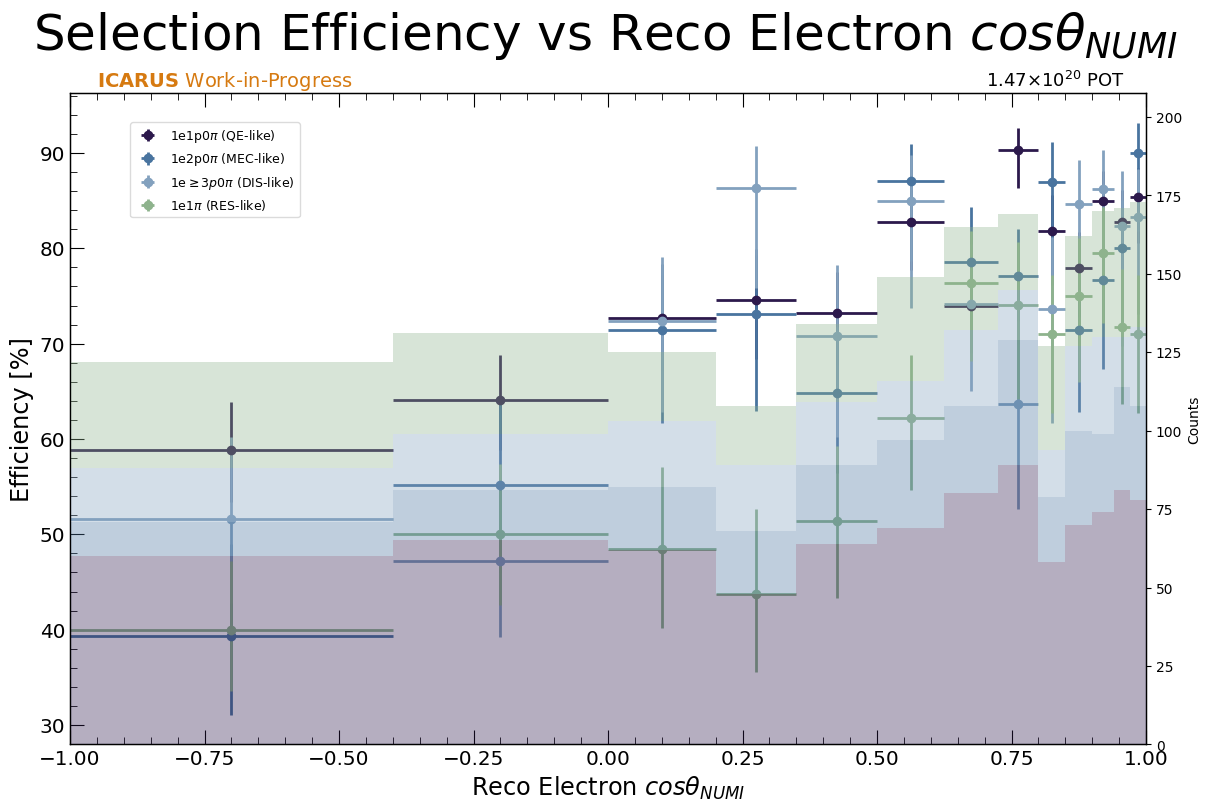

In [132]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_interaction/efficiency_vs_electronAngle.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_reco_ele_beam_cosTheta.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc=None,
    hist_legend_anchor  = (0.0, 0.9),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.05, 0.8))
plt.show(fig)

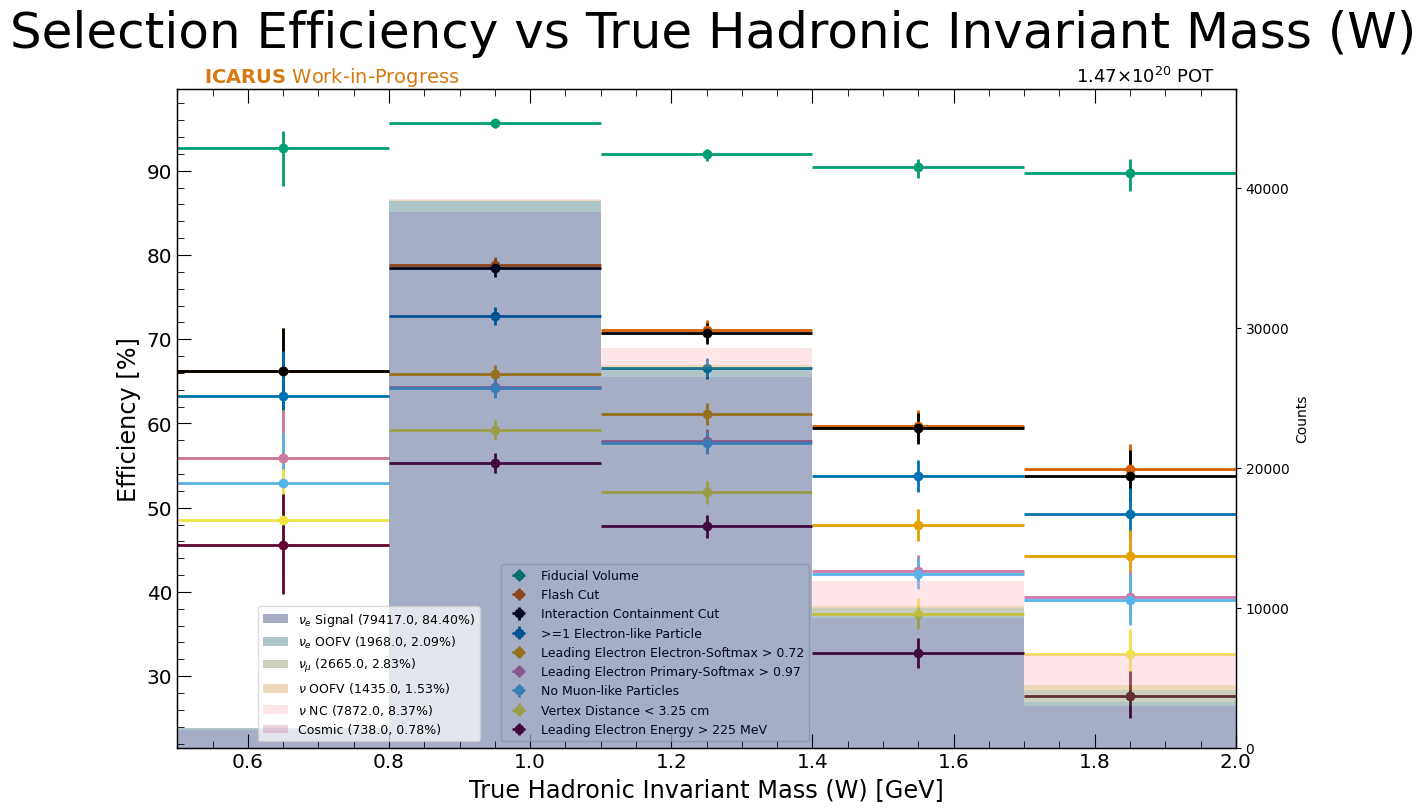

In [138]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_trueInvMass.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_hadronic_invariant_mass.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.07, 0.0),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.3, 0.0))
plt.show(fig)

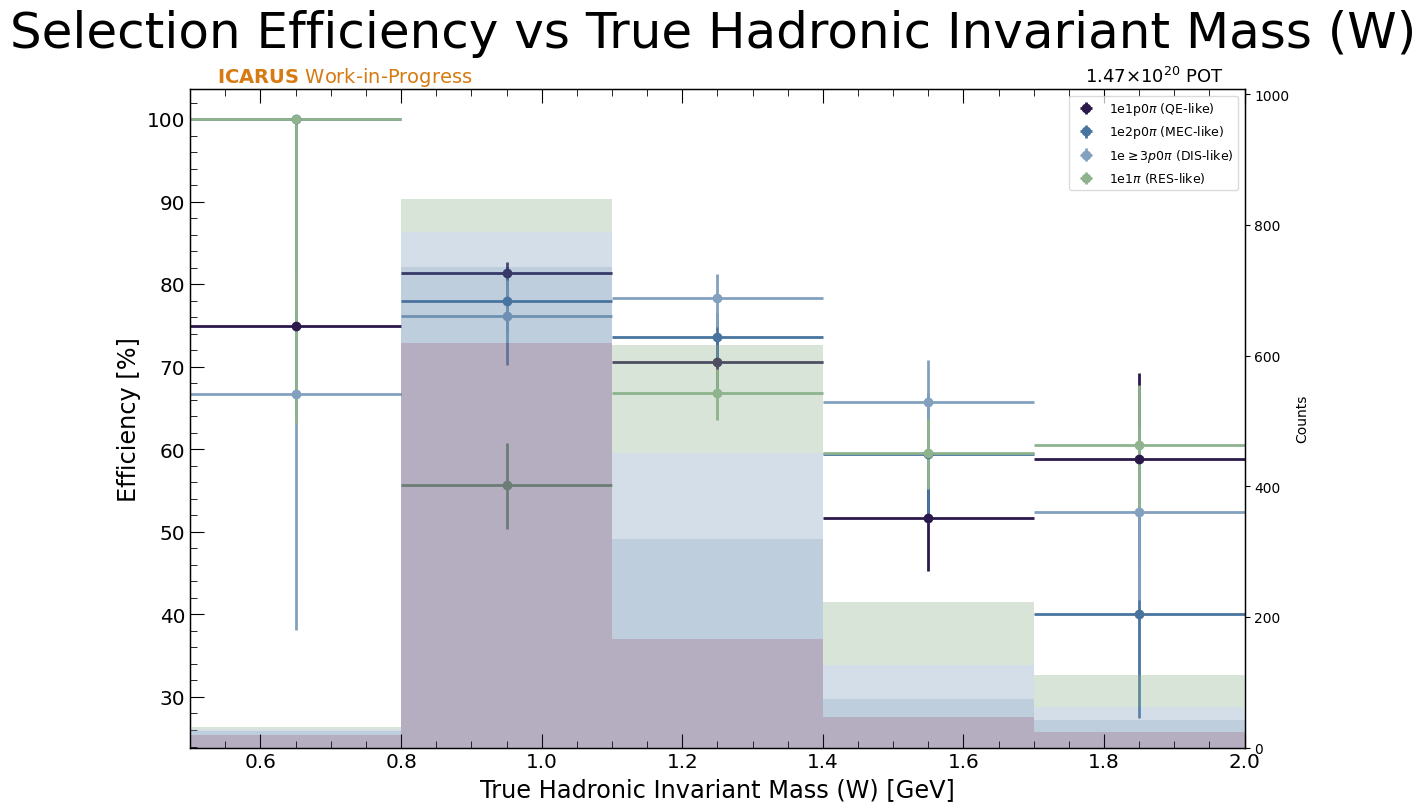

In [143]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_interaction/efficiency_vs_trueInvMass.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_hadronic_invariant_mass.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc=None,
    hist_legend_anchor  = (0.07, 0.0),
    eff_legend_loc      = 'upper right',
    eff_legend_anchor   = (1.0, 1.0))
plt.show(fig)

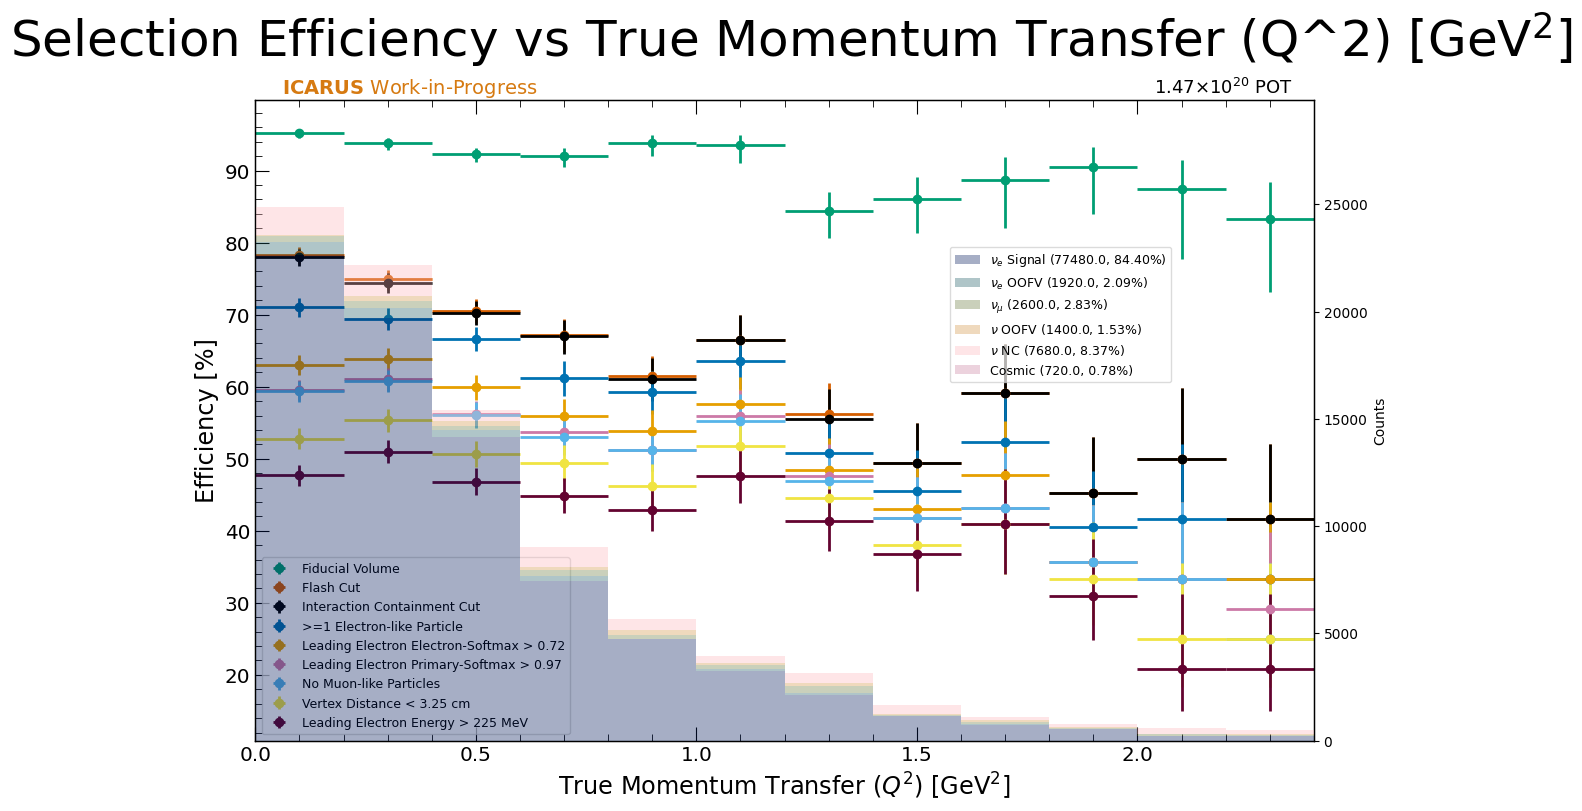

In [149]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_energyCut/efficiency_vs_trueMomentumTransfer.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/neutrino_type/plot_true_momentum_transfer.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc='lower left',
    hist_legend_anchor  = (0.65, 0.55),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.0, 0.0))
plt.show(fig)

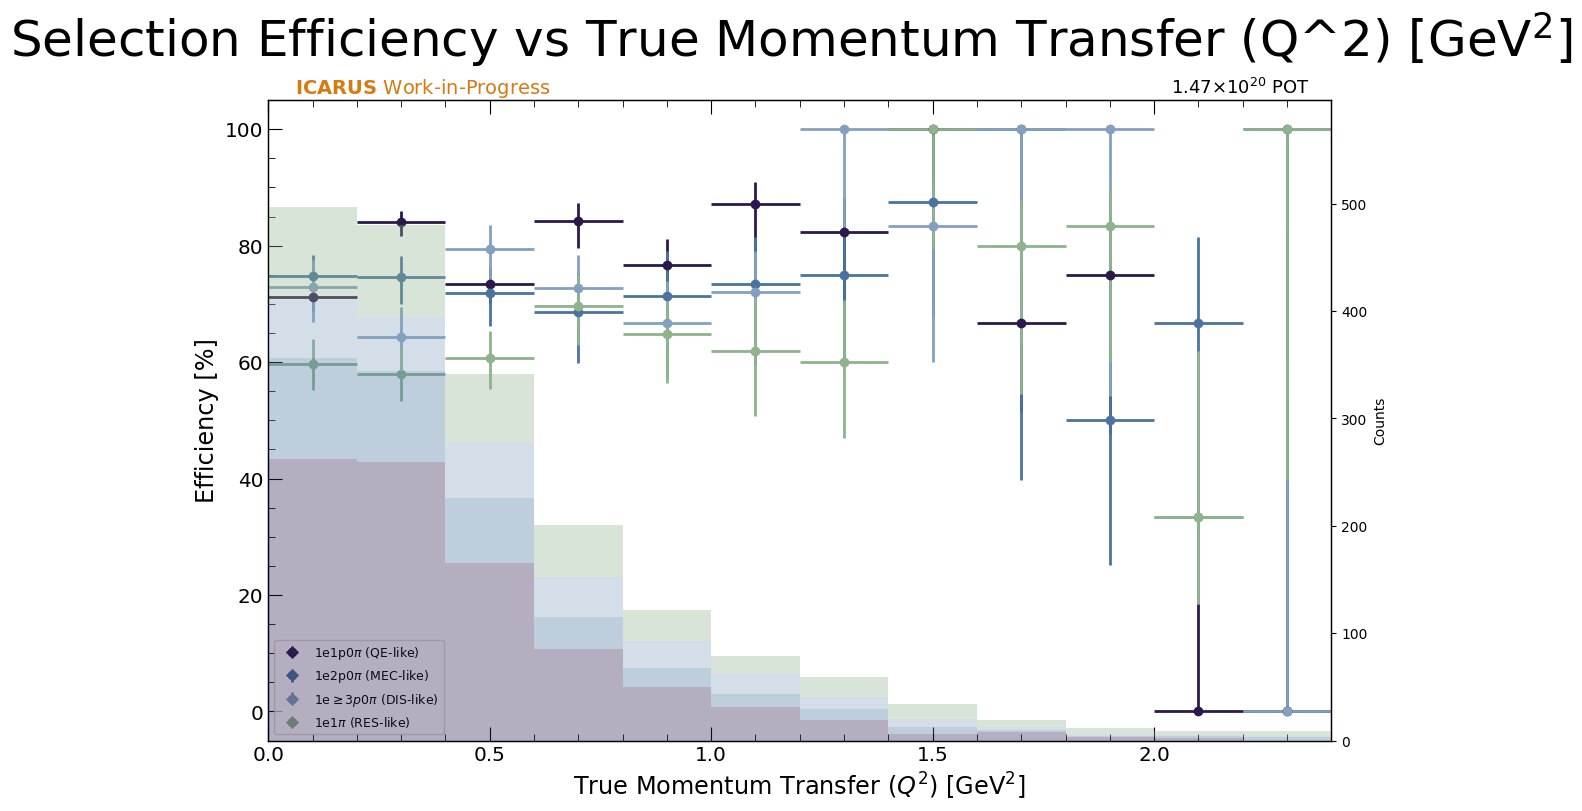

In [151]:
fig = overlay_hist_on_efficiency(
    eff_path  = '/nashome/m/micarrig/icarus/nuESpine/plots/efficiency_reco_interaction/efficiency_vs_trueMomentumTransfer.pkl',
    hist_path = '/nashome/m/micarrig/icarus/nuESpine/plots/reco_neutrino_interaction/plot_true_momentum_transfer.pkl',
    alpha=0.35, figsize=(12, 8),
    hist_legend_loc=None,
    hist_legend_anchor  = (0.65, 0.55),
    eff_legend_loc      = 'lower left',
    eff_legend_anchor   = (0.0, 0.0))
plt.show(fig)

# Compare to nue CC Np 0Pi Selection

In [15]:
fin = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCNp0pi.root:events/debugMC/all")

In [16]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_single_electron", "1 Electron-like Particle"))
selections.append(selection("reco_multiproton", ">=1 Proton-like Particles"))
selections.append(selection("reco_no_charged_pions", "No Charged Pion-like Particles"))
selections.append(selection("reco_leading_electron_cut_axial_spread", "Axial Spread > 0.02"))
selections.append(selection("reco_leading_electron_cut_directional_spread", "Directional Spread < 0.25"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 7.5 cm"))
selections.append(selection("reco_good_proton", "Good Proton-like Particle"))
selections.append(selection("reco_good_electron", "Good Electron-like Particle"))

In [17]:
hists = get_effHists('reco_leading_electron_ke', fin, selections, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron KE Efficiency", "Leading Electron KE (MeV)", "Efficiency", range=(0.1, 1.2))

c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (618/618)
Applying selection: Flash Cut
Efficiency after Flash Cut: 0.6893 (426/618)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.6796 (420/618)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.6440 (398/618)
Applying selection: 1 Electron-like Particle
Efficiency after 1 Electron-like Particle: 0.5631 (348/618)
Applying selection: >=1 Proton-like Particles
Efficiency after >=1 Proton-like Particles: 0.4094 (253/618)
Applying selection: No Charged Pion-like Particles
Efficiency after No Charged Pion-like Particles: 0.3430 (212/618)
Applying selection: Axial Spread > 0.02
Efficiency after Axial Spread > 0.02: 0.3366 (208/618)
Applying selection: Directional Spread < 0.25
Efficiency after Directional Spread < 0.25: 0.3350 (207/618)
Applying selection: Vertex Distance < 7.5 cm
Efficiency after Vertex Distance < 7.5 cm: 0.3220 (199/618)
Applying selection: Good Pro

Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 15 points have been skippe

## Compare SPINE and Pandora Pre Selection

In [225]:
f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_eff/t_eff")
f_spine = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/all")

In [226]:
f_pandora.keys()

['tNueEnergy',
 'rShowerEnergy',
 'rShowerDeDx',
 'rShowerDensity',
 'rShowerConversionGap',
 'rLongestTrackLength',
 'rBarycenterDeltaZ',
 'rBarycenterRadius',
 'rFiducial',
 'rShowerContained',
 'rMuonChi2',
 'tInteractionMode',
 'tNeutrinoType',
 'rSubleadingShowerEnergy',
 'rShowerEResidual',
 'rSecondaryShowerEResidual',
 'rNeutrinoScore',
 'tShowerLength',
 'rShowerLenResidual',
 'rVertexResidual',
 'tShowerE',
 'tSubleadingShowerE',
 'kLongestTrackLengthResidual',
 'tTLongestTrackLength',
 'kShowerCosAngle',
 'kShowerP',
 'tFiducial',
 'rShowerLength',
 'rShowerEndX',
 'rShowerEndY',
 'rShowerEndZ',
 'rShowerStartX',
 'rShowerStartY',
 'rShowerStartZ',
 'rVertexCryo',
 'rTruthPDGID',
 'rClearCosmic',
 'rLargestShowerCut',
 'tGoodNue',
 'Run',
 'Subrun',
 'Evt',
 'Slice']

In [229]:
f_pandora.keys(), f_spine.keys()

spineSel = (f_spine['true_category'].array() == 0)

#pandoraSel = (f_pandora['tNeutrinoType'].array() == 2) & (f_pandora['tFiducial'].array() == 1)
pandoraSel = (f_pandora['tGoodNue'].array() == 1)

spineEvents = len(f_spine['true_neutrino_energy'].array()[spineSel])
pandoraEvents = len(f_pandora['tNueEnergy'].array()[pandoraSel])

print("There are {} events in the SPINE file and {} events in the Pandora file.".format(spineEvents, pandoraEvents))
print("There are {} unique events in the SPINE file and {} unique events in the Pandora file.".format(len(np.unique(f_spine['true_neutrino_energy'].array()[spineSel])), len(np.unique(f_pandora['tNueEnergy'].array()[pandoraSel]))))

There are 618 events in the SPINE file and 626 events in the Pandora file.
There are 435 unique events in the SPINE file and 557 unique events in the Pandora file.


In [96]:
spineNu = ak.count_nonzero(np.abs(f_spine['true_pdg'].array()) == 12)
pandoraNu = ak.count_nonzero(np.abs(f_pandora['tNeutrinoType'].array()) == 2)

print("There are {} true electron neutrinos in the SPINE file.".format(spineNu))
print("There are {} true electron neutrinos in the Pandora file.".format(pandoraNu))

There are 1656 true electron neutrinos in the SPINE file.
There are 955 true electron neutrinos in the Pandora file.


In [97]:
spine_vals = ak.to_numpy(f_spine['true_neutrino_energy'].array()[spineSel])
pandora_vals = ak.to_numpy(f_pandora['tNueEnergy'].array()[pandoraSel])

all_vals = np.union1d(spine_vals, pandora_vals)

for v in all_vals:
    if np.isnan(v):
        spine_count = np.count_nonzero(np.isnan(spine_vals))
        pandora_count = np.count_nonzero(np.isnan(pandora_vals))
    else:
        spine_count = np.count_nonzero(spine_vals == v)
        pandora_count = np.count_nonzero(pandora_vals == v)
    if spine_count != pandora_count:
        print("Neutrino energy {}, SPINE count {}, Pandora count {}".format(v, spine_count, pandora_count))

Neutrino energy 0.170705646276474, SPINE count 2, Pandora count 1
Neutrino energy 0.3943537473678589, SPINE count 2, Pandora count 1
Neutrino energy 0.4617410898208618, SPINE count 2, Pandora count 1
Neutrino energy 0.48265162110328674, SPINE count 2, Pandora count 1
Neutrino energy 0.48549866676330566, SPINE count 1, Pandora count 0
Neutrino energy 0.5533434152603149, SPINE count 3, Pandora count 1
Neutrino energy 0.5987469553947449, SPINE count 2, Pandora count 1
Neutrino energy 0.6143943667411804, SPINE count 4, Pandora count 1
Neutrino energy 0.6334453225135803, SPINE count 2, Pandora count 1
Neutrino energy 0.6344477534294128, SPINE count 2, Pandora count 1
Neutrino energy 0.6931791305541992, SPINE count 2, Pandora count 1
Neutrino energy 0.7048733234405518, SPINE count 2, Pandora count 1
Neutrino energy 0.7250644564628601, SPINE count 1, Pandora count 2
Neutrino energy 0.7479201555252075, SPINE count 1, Pandora count 2
Neutrino energy 0.7523621916770935, SPINE count 1, Pandora co

In [107]:
# True interactions, vs reco interactions, vs total neutrinos

f_event = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/eventLevel")

f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_evt/t_evt")

f_pandoraEvt.keys()

['CutType', 'SpillCutType', 'NumNuE', 'nNue', 'nNumu', 'Run', 'Subrun', 'Evt']

In [108]:
c1 = r.TCanvas("c1", "c1", 800, 600)
l = r.TLegend(0.6,0.6,0.88,0.88)

t_int = f_event['event_ntrue'].array()
r_int = f_event['event_nreco'].array()
t_nu = f_event['event_nnu'].array()
t_numu = f_event['event_nnu_mu'].array()
t_nue = f_event['event_nnu_e'].array()

h_t_int = r.TH1F("h_t_int", "True Interactions", 100, 0, 100)
h_r_int = r.TH1F("h_r_int", "Reconstructed Interactions", 100, 0, 100)
h_t_nu = r.TH1F("h_t_nu", "Total Neutrinos", 10, 0, 10)
h_t_numu = r.TH1F("h_t_numu", "Muon Neutrinos", 10, 0, 10)
h_t_nue = r.TH1F("h_t_nue", "Electron Neutrinos", 10, 0, 10)

h_t_int.FillN(len(t_int), arr.array('d', t_int), np.ones(len(t_int)))
h_r_int.FillN(len(r_int), arr.array('d', r_int), np.ones(len(r_int)))
h_t_nu.FillN(len(t_nu), arr.array('d', t_nu), np.ones(len(t_nu)))
h_t_numu.FillN(len(t_numu), arr.array('d', t_numu), np.ones(len(t_numu)))
h_t_nue.FillN(len(t_nue), arr.array('d', t_nue), np.ones(len(t_nue)))

h_t_int.GetYaxis().SetRangeUser(0, max(h_t_int.GetMaximum(), h_r_int.GetMaximum(), h_t_nu.GetMaximum())*1.2)
h_t_int.SetLineColor(r.kBlack)
h_t_int.Draw("HIST")
l.AddEntry(h_t_int, "True Interactions", "l")
h_r_int.SetLineColor(r.kRed)
l.AddEntry(h_r_int, "Reconstructed Interactions", "l")
h_r_int.Draw("HIST SAME")
h_t_nu.SetLineColor(r.kBlue)
l.AddEntry(h_t_nu, "Total Neutrinos", "l")
h_t_nu.Draw("HIST SAME")

l.Draw()
c1.Draw()

h_t_int.GetMaximum(), h_r_int.GetMaximum(), h_t_nu.GetMaximum()
print(t_int, r_int, t_nu)

[33, 33, 37, 22, 37, 26, 27, 24, 19, ..., 33, 32, 24, 37, 24, 36, 19, 25, 33] [48, 38, 44, 30, 51, 39, 38, 30, 27, ..., 42, 44, 30, 48, 31, 52, 28, 37, 44] [1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, ..., 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TROOT::Append>: Replacing existing TH1: h_t_int (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_r_int (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_nu (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_numu (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_nue (Potential memory leak).


In [109]:
t_nueP = f_pandoraEvt['nNue'].array()
t_numuP = f_pandoraEvt['nNumu'].array()

h_t_nueP = r.TH1F("h_t_nueP", "Electron Neutrinos (Pandora)", 10, 0, 10)
h_t_numuP = r.TH1F("h_t_numuP", "Muon Neutrinos (Pandora)", 10, 0, 10)

h_t_nueP.FillN(len(t_nueP), arr.array('d', t_nueP), np.ones(len(t_nueP)))
h_t_numuP.FillN(len(t_numuP), arr.array('d', t_numuP), np.ones(len(t_numuP)))

l = r.TLegend(0.6,0.6,0.88,0.88)

h_t_nueP.GetYaxis().SetRangeUser(0, max(h_t_nueP.GetMaximum(), h_t_numuP.GetMaximum())*1.2)
h_t_nueP.SetLineColor(r.kGreen+2)
h_t_nueP.Draw("HIST")
l.AddEntry(h_t_nueP, "Electron Neutrinos (Pandora)", "l")
h_t_numuP.SetLineColor(r.kMagenta)
l.AddEntry(h_t_numuP, "Muon Neutrinos (Pandora)", "l")
h_t_numuP.Draw("HIST SAME") 

l.Draw()
c1.Draw()

n_nueP = ak.count_nonzero(t_nueP)
n_numuP = ak.count_nonzero(t_numuP)
n_totalP = n_nueP + n_numuP

print(f"There are {n_nueP} electron neutrinos and {n_numuP} muon neutrinos, for a total of {n_totalP} neutrinos (Pandora).")

There are 2081 electron neutrinos and 43287 muon neutrinos, for a total of 45368 neutrinos (Pandora).


Warning in <TROOT::Append>: Replacing existing TH1: h_t_nueP (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_t_numuP (Potential memory leak).


In [111]:
c1.Clear()
l = r.TLegend(0.6,0.6,0.88,0.88)

h_t_nu.SetLineColor(r.kBlack)
h_t_nu.GetYaxis().SetRangeUser(0, max(h_t_nu.GetMaximum(), h_t_numu.GetMaximum(), h_t_nue.GetMaximum())*1.2)
h_t_nu.Draw("HIST")
l.AddEntry(h_t_nu, "Total Neutrinos", "l")
h_t_numu.SetLineColor(r.kRed)
h_t_numu.Draw("HIST SAME")
l.AddEntry(h_t_numu, "Muon Neutrinos", "l")
h_t_nue.SetLineColor(r.kBlue)
h_t_nue.Draw("HIST SAME")
l.AddEntry(h_t_nue, "Electron Neutrinos", "l")
l.Draw()
c1.Draw()

n_total, n_nue, n_numu = 0, 0, 0
for i in range(h_t_nu.GetNbinsX()+1):
    n_total += h_t_nu.GetBinContent(i+1) * i
    n_nue += h_t_nue.GetBinContent(i+1) * i
    n_numu += h_t_numu.GetBinContent(i+1) * i

print("There are {} total neutrinos, {} electron neutrinos, and {} muon neutrinos (SPINE).".format(n_total, n_nue, n_numu))


There are 45368.0 total neutrinos, 2081.0 electron neutrinos, and 43287.0 muon neutrinos (SPINE).


In [41]:
## compare efficiency SPINE vs Pandora
## denominator is going to be total true nue, numerator is interactions/slices passing selections

# f_spine = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/all")
# f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_eff/t_eff")

# f_spineEvt = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/debugMC/eventLevel")
# f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/debug_spine2.root:t_evt/t_evt")

f_spine = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/NuMIFull/all")
f_pandora = uproot.open("root://fndcadoor.fnal.gov://icarus/scratch/users/micarrig/nueInclusive4/outputs/00/output_0.root:t_eff/t_eff")

f_spineEvt = uproot.open("/nashome/m/micarrig/icarus/nuESpine/output_nueCCInclusive2.root:events/NuMIFull/eventLevel")
f_pandoraEvt = uproot.open("root://fndcadoor.fnal.gov://icarus/scratch/users/micarrig/nueInclusive4/outputs/00/output_0.root:t_evt/t_evt")

nEvt_spine = ak.sum(f_spineEvt['event_nnu_e'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_spine, nEvt_pandora))
if nEvt_spine != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 14938.0 electron neutrino events in the SPINE file and 14938.0 electron neutrino events in the Pandora file.


In [42]:
# spine_selections = []
# spine_selections.append(selection("reco_no_cut", "No Cut"))
# spine_selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
# spine_selections.append(selection("reco_valid_flashmatch", "Flash Cut"))
# spine_selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
# spine_selections.append(selection("reco_track_length", "Longest Track Length < 190 cm"))
# spine_selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
#spine_selections.append(selection("reco_leading_electron_containment_cut", "Leading Electron Containment Cut"))

spine_selections = []
spine_selections.append(selection("reco_no_cut", "No Cut"))
spine_selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
spine_selections.append(selection("reco_flash_cut", "Flash Cut"))
spine_selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
spine_selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
spine_selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
spine_selections.append(selection("reco_muon_multiplicity", "0 Muon-like Particles", operator='==', threshold=0))
spine_selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
spine_selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))

pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))


In [43]:
bins  = arr.array('d', [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000])

In [44]:
hists_spine = get_effHists('reco_leading_electron_energy', f_spine, spine_selections,total=nEvt_spine, bins=bins, xmin=0, xmax=5000)

Applying selection: No Cut
total entries in selection: 11306582
Selected entries: 11046192
Purity: 4516/11046192 = 0.0004
Efficiency after No Cut: 1.0000 (4516/4516)
Applying selection: Fiducial Cut
total entries in selection: 4130763
Selected entries: 4023929
Purity: 4159/4023929 = 0.0010
Efficiency after Fiducial Cut: 0.9209 (4159/4516)
Applying selection: Flash Cut
total entries in selection: 123209
Selected entries: 120865
Purity: 3117/120865 = 0.0258
Efficiency after Flash Cut: 0.6902 (3117/4516)
Applying selection: Interaction Containment Cut
total entries in selection: 59861
Selected entries: 57539
Purity: 2983/57539 = 0.0518
Efficiency after Interaction Containment Cut: 0.6605 (2983/4516)
Applying selection: Vertex Distance < 3.25 cm
total entries in selection: 5029
Selected entries: 4802
Purity: 2402/4802 = 0.5002
Efficiency after Vertex Distance < 3.25 cm: 0.5319 (2402/4516)
Applying selection: >=1 Electron-like Particle
total entries in selection: 5029
Selected entries: 4802

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [45]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)

Applying selection: No Cut
total entries in selection: 204728
Selected entries: 204728
Purity: 3542/204728 = 0.0173
Efficiency after No Cut: 1.0000 (3542/3542)
Applying selection: >= 1 Shower
total entries in selection: 39433
Selected entries: 39433
Purity: 2404/39433 = 0.0610
Efficiency after >= 1 Shower: 0.6787 (2404/3542)
Applying selection: Clear Cosmic
total entries in selection: 39433
Selected entries: 39433
Purity: 2404/39433 = 0.0610
Efficiency after Clear Cosmic: 0.6787 (2404/3542)
Applying selection: Fiducial Cut
total entries in selection: 24327
Selected entries: 24327
Purity: 2341/24327 = 0.0962
Efficiency after Fiducial Cut: 0.6609 (2341/3542)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 22432
Selected entries: 22432
Purity: 2195/22432 = 0.0979
Efficiency after Barycenter Delta Z < 100 cm: 0.6197 (2195/3542)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 21867
Selected entries: 21867
Purity: 2169/21867 = 0.0992
Eff

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [46]:
print_selection_stats(pandora_selections)


Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (3542/3542) 0.2371 (3542/14938.0) 0.0173 (3542/204728)
>= 1 Shower                           0.6787 (2404/3542) 0.1609 (2404/14938.0) 0.0610 (2404/39433)
Clear Cosmic                          0.6787 (2404/3542) 0.1609 (2404/14938.0) 0.0610 (2404/39433)
Fiducial Cut                          0.6609 (2341/3542) 0.1567 (2341/14938.0) 0.0962 (2341/24327)
Barycenter Delta Z < 100 cm           0.6197 (2195/3542) 0.1469 (2195/14938.0) 0.0979 (2195/22432)
Barycenter Radius < 100 cm            0.6124 (2169/3542) 0.1452 (2169/14938.0) 0.0992 (2169/21867)
Longest Track < 190 cm                0.5584 (1978/3542) 0.1324 (1978/14938.0) 0.1282 (1978/15431)
Shower Contained                      0.5347 (1894/3542) 0.1268 (1894/14938.0) 0.1290 (1894/146

In [47]:
print_selection_stats(spine_selections)


Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (4516/4516) 0.3023 (4516/14938.0) 0.0004 (4516/11046192)
Fiducial Cut                          0.9209 (4159/4516) 0.2784 (4159/14938.0) 0.0010 (4159/4023929)
Flash Cut                             0.6902 (3117/4516) 0.2087 (3117/14938.0) 0.0258 (3117/120865)
Interaction Containment Cut           0.6605 (2983/4516) 0.1997 (2983/14938.0) 0.0518 (2983/57539)
Vertex Distance < 3.25 cm             0.5319 (2402/4516) 0.1608 (2402/14938.0) 0.5002 (2402/4802)
>=1 Electron-like Particle            0.5319 (2402/4516) 0.1608 (2402/14938.0) 0.5002 (2402/4802)
0 Muon-like Particles                 0.5268 (2379/4516) 0.1593 (2379/14938.0) 0.5511 (2379/4317)
Leading Electron Softmax > 0.72       0.4885 (2206/4516) 0.1477 (2206/14938.0) 0.6623 (2206/3

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


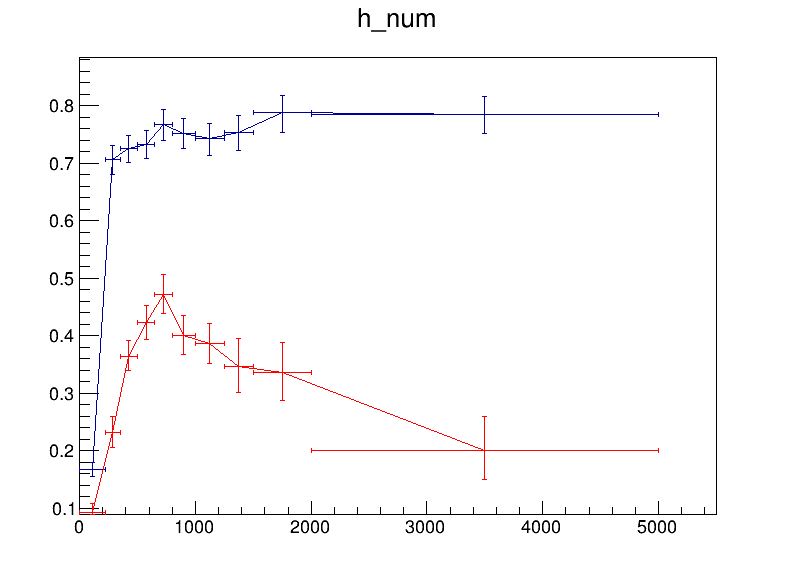

In [48]:
c1 = r.TCanvas("c1", "c1", 800, 600)

h_spine_eff = hists_spine[list(hists_spine)[-1]]
h_pandora_eff = hists_pandora[list(hists_pandora)[-1]]

h_spine_eff.Draw()
h_pandora_eff.SetLineColor(r.kRed)
h_pandora_eff.Draw("same")

e_pandora = pandora_selections[-1].efficiency
p_pandora = pandora_selections[-1].purity

e_spine = spine_selections[-1].efficiency
p_spine = spine_selections[-1].purity

c1.Draw()

# Compare pandora w/ and w/o NuGraph

In [64]:
f_nugraph = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_nugraphScore.root:t_eff/t_eff")
f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_trackScore.root:t_eff/t_eff")

f_nugraphEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_nugraphScore.root:t_evt/t_evt")
f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraph_trackScore.root:t_evt/t_evt")

nEvt_nugraph = ak.sum(f_nugraphEvt['nNue'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_nugraph, nEvt_pandora))
if nEvt_nugraph != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 549.0 electron neutrino events in the SPINE file and 549.0 electron neutrino events in the Pandora file.


In [65]:
pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))

nugraph_selections = []
nugraph_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
nugraph_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
nugraph_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
nugraph_selections.append(selection("rFiducial", "Fiducial Cut"))
nugraph_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
nugraph_selections.append(selection("rShowerContained", "Shower Contained"))
nugraph_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))   
nugraph_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
nugraph_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5)) 

In [66]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)
hists_nugraph = get_effHists('rShowerEnergy', f_nugraph, nugraph_selections, total=nEvt_nugraph, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)

Applying selection: No Cut
total entries in selection: 9121
Selected entries: 9121
Purity: 213/9121 = 0.0234
Efficiency after No Cut: 1.0000 (213/213)
Applying selection: >= 1 Shower
total entries in selection: 1848
Selected entries: 1848
Purity: 140/1848 = 0.0758
Efficiency after >= 1 Shower: 0.6573 (140/213)
Applying selection: Clear Cosmic
total entries in selection: 1848
Selected entries: 1848
Purity: 140/1848 = 0.0758
Efficiency after Clear Cosmic: 0.6573 (140/213)
Applying selection: Fiducial Cut
total entries in selection: 1258
Selected entries: 1258
Purity: 139/1258 = 0.1105
Efficiency after Fiducial Cut: 0.6526 (139/213)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 1176
Selected entries: 1176
Purity: 134/1176 = 0.1139
Efficiency after Barycenter Delta Z < 100 cm: 0.6291 (134/213)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 1151
Selected entries: 1151
Purity: 131/1151 = 0.1138
Efficiency after Barycenter Radius < 100

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [67]:
print("Pandora Selections:")
print_selection_stats(pandora_selections)
print("NuGraph Selections:")
print_selection_stats(nugraph_selections)

Pandora Selections:

Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                  1.0000 (213/213)   0.3880 (213/549.0) 0.0234 (213/9121)
>= 1 Shower                             0.6573 (140/213)   0.2550 (140/549.0) 0.0758 (140/1848)
Clear Cosmic                            0.6573 (140/213)   0.2550 (140/549.0) 0.0758 (140/1848)
Fiducial Cut                            0.6526 (139/213)   0.2532 (139/549.0) 0.1105 (139/1258)
Barycenter Delta Z < 100 cm             0.6291 (134/213)   0.2441 (134/549.0) 0.1139 (134/1176)
Barycenter Radius < 100 cm              0.6150 (131/213)   0.2386 (131/549.0) 0.1138 (131/1151)
Longest Track < 190 cm                  0.5681 (121/213)   0.2204 (121/549.0) 0.1470 (121/823)
Shower Contained                        0.5681 (121/213)   0.2204 (121/549.0) 0.1511 (121/801)
Sho

In [68]:
h_pandoraNu_eff = hists_pandora[list(hists_pandora)[-1]]
h_nuGraph_eff = hists_nugraph[list(hists_nugraph)[-1]]

e_pandoraNu = pandora_selections[-1].efficiency
p_pandoraNu = pandora_selections[-1].purity

e_nu = nugraph_selections[-1].efficiency
p_nu = nugraph_selections[-1].purity

## Use Nue enhanced sample

In [54]:
f_nugraph = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_nugraphScore.root:t_eff/t_eff")
f_pandora = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_trackScore.root:t_eff/t_eff")

f_nugraphEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_nugraphScore.root:t_evt/t_evt")
f_pandoraEvt = uproot.open("/nashome/m/micarrig/icarus/NuE/output_nugraphE_trackScore.root:t_evt/t_evt")

nEvt_nugraph = ak.sum(f_nugraphEvt['nNue'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_nugraph, nEvt_pandora))
if nEvt_nugraph != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 19259.0 electron neutrino events in the SPINE file and 19259.0 electron neutrino events in the Pandora file.


In [55]:
pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))

nugraph_selections = []
nugraph_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
nugraph_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
nugraph_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
nugraph_selections.append(selection("rFiducial", "Fiducial Cut"))
nugraph_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
nugraph_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
nugraph_selections.append(selection("rShowerContained", "Shower Contained"))
nugraph_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))   
nugraph_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
nugraph_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5)) 

In [56]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=50, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1)
hists_nugraph = get_effHists('rShowerEnergy', f_nugraph, nugraph_selections, total=nEvt_nugraph, bins=50, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1)

Applying selection: No Cut
total entries in selection: 15155
Selected entries: 15155
Purity: 7361/15155 = 0.4857
Efficiency after No Cut: 1.0000 (7361/7361)
Applying selection: >= 1 Shower
total entries in selection: 8291
Selected entries: 8291
Purity: 4918/8291 = 0.5932
Efficiency after >= 1 Shower: 0.6681 (4918/7361)
Applying selection: Clear Cosmic
total entries in selection: 8291
Selected entries: 8291
Purity: 4918/8291 = 0.5932
Efficiency after Clear Cosmic: 0.6681 (4918/7361)
Applying selection: Fiducial Cut
total entries in selection: 5540
Selected entries: 5540
Purity: 4797/5540 = 0.8659
Efficiency after Fiducial Cut: 0.6517 (4797/7361)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 5353
Selected entries: 5353
Purity: 4647/5353 = 0.8681
Efficiency after Barycenter Delta Z < 100 cm: 0.6313 (4647/7361)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 5280
Selected entries: 5280
Purity: 4595/5280 = 0.8703
Efficiency after Bary

Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TGraphAsymmErrors::Divide>: Number of graph points is different than histogram bins - 4 points have been skipped
Wa

In [57]:
print("Pandora Selections:")
print_selection_stats(pandora_selections)
print("NuGraph Selections:")
print_selection_stats(nugraph_selections)

Pandora Selections:

Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (7361/7361) 0.3822 (7361/19259.0) 0.4857 (7361/15155)
>= 1 Shower                           0.6681 (4918/7361) 0.2554 (4918/19259.0) 0.5932 (4918/8291)
Clear Cosmic                          0.6681 (4918/7361) 0.2554 (4918/19259.0) 0.5932 (4918/8291)
Fiducial Cut                          0.6517 (4797/7361) 0.2491 (4797/19259.0) 0.8659 (4797/5540)
Barycenter Delta Z < 100 cm           0.6313 (4647/7361) 0.2413 (4647/19259.0) 0.8681 (4647/5353)
Barycenter Radius < 100 cm            0.6242 (4595/7361) 0.2386 (4595/19259.0) 0.8703 (4595/5280)
Longest Track < 190 cm                0.5768 (4246/7361) 0.2205 (4246/19259.0) 0.8656 (4246/4905)
Shower Contained                      0.5597 (4120/7361) 0.2139 (4120/19259.0) 0.8

# Compare Pandora w/ and w/o CVN

In [58]:
f_cvn = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/CVN/merged_output.root:t_eff/t_eff")
f_pandora = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/noCVN/merged_output.root:t_eff/t_eff")

f_cvnEvt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/CVN/merged_output.root:t_evt/t_evt")
f_pandoraEvt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveCVN/noCVN/merged_output.root:t_evt/t_evt")

nEvt_cvn = ak.sum(f_cvnEvt['nNue'].array())
nEvt_pandora = ak.sum(f_pandoraEvt['nNue'].array())

print("There are {} electron neutrino events in the SPINE file and {} electron neutrino events in the Pandora file.".format(nEvt_cvn, nEvt_pandora))
if nEvt_cvn != nEvt_pandora:
    print("Warning: number of electron neutrino events does not match between SPINE and Pandora files.")

There are 4733.0 electron neutrino events in the SPINE file and 4733.0 electron neutrino events in the Pandora file.


In [59]:
pandora_selections = []
pandora_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
pandora_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
pandora_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
pandora_selections.append(selection("rFiducial", "Fiducial Cut"))
pandora_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
pandora_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
pandora_selections.append(selection("rShowerContained", "Shower Contained"))
pandora_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))
pandora_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
pandora_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5))

cvn_selections = []
cvn_selections.append(selection("rFiducial", "No Cut", operator='!=', threshold=-1)) #use fiducial as standin for no cut
cvn_selections.append(selection("rLargestShowerCut", ">= 1 Shower"))
cvn_selections.append(selection("rClearCosmic", "Clear Cosmic", operator='!=', threshold=1))
cvn_selections.append(selection("rFiducial", "Fiducial Cut"))
cvn_selections.append(selection("rBarycenterDeltaZ", "Barycenter Delta Z < 100 cm", operator='<', threshold=100))
cvn_selections.append(selection("rBarycenterRadius", "Barycenter Radius < 100 cm", operator='<', threshold=100))
cvn_selections.append(selection("kCVNNueScore", "CVN NuE Cut > 0.85", operator='>', threshold=0.85))
cvn_selections.append(selection("rLongestTrackLength", "Longest Track < 190 cm", operator='<', threshold=190))
cvn_selections.append(selection("rShowerContained", "Shower Contained"))
cvn_selections.append(selection("rShowerDeDx", "Shower dE/dx < 3.625 MeV/cm", operator='<', threshold=3.625))   
cvn_selections.append(selection("rShowerConversionGap", "Shower Conversion Gap < 3.25 cm", operator='<', threshold=3.25))
cvn_selections.append(selection("rShowerDensity", "Shower Density > 4.5", operator='>', threshold=4.5)) 

In [60]:
hists_pandora = get_effHists('rShowerEnergy', f_pandora, pandora_selections, total=nEvt_pandora, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)
hists_cvn = get_effHists('rShowerEnergy', f_cvn, cvn_selections, total=nEvt_cvn, bins=bins, xmin=0, xmax=5, eff_var='tGoodNue', signal_index=1, scale=1000)

Applying selection: No Cut
total entries in selection: 63790
Selected entries: 63790
Purity: 1117/63790 = 0.0175
Efficiency after No Cut: 1.0000 (1117/1117)
Applying selection: >= 1 Shower
total entries in selection: 10560
Selected entries: 10560
Purity: 675/10560 = 0.0639
Efficiency after >= 1 Shower: 0.6043 (675/1117)
Applying selection: Clear Cosmic
total entries in selection: 10560
Selected entries: 10560
Purity: 675/10560 = 0.0639
Efficiency after Clear Cosmic: 0.6043 (675/1117)
Applying selection: Fiducial Cut
total entries in selection: 6782
Selected entries: 6782
Purity: 655/6782 = 0.0966
Efficiency after Fiducial Cut: 0.5864 (655/1117)
Applying selection: Barycenter Delta Z < 100 cm
total entries in selection: 6265
Selected entries: 6265
Purity: 625/6265 = 0.0998
Efficiency after Barycenter Delta Z < 100 cm: 0.5595 (625/1117)
Applying selection: Barycenter Radius < 100 cm
total entries in selection: 6126
Selected entries: 6126
Purity: 615/6126 = 0.1004
Efficiency after Barycen

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [61]:
print("Pandora Selections:")
print_selection_stats(pandora_selections)
print("CVN Selections:")
print_selection_stats(cvn_selections)

Pandora Selections:

Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                                1.0000 (1117/1117) 0.2360 (1117/4733.0) 0.0175 (1117/63790)
>= 1 Shower                            0.6043 (675/1117)  0.1426 (675/4733.0) 0.0639 (675/10560)
Clear Cosmic                           0.6043 (675/1117)  0.1426 (675/4733.0) 0.0639 (675/10560)
Fiducial Cut                           0.5864 (655/1117)  0.1384 (655/4733.0) 0.0966 (655/6782)
Barycenter Delta Z < 100 cm            0.5595 (625/1117)  0.1321 (625/4733.0) 0.0998 (625/6265)
Barycenter Radius < 100 cm             0.5506 (615/1117)  0.1299 (615/4733.0) 0.1004 (615/6126)
Longest Track < 190 cm                 0.4987 (557/1117)  0.1177 (557/4733.0) 0.1294 (557/4303)
Shower Contained                       0.4781 (534/1117)  0.1128 (534/4733.0) 0.1291 (534/413

In [62]:
h_cvn_eff = hists_cvn[list(hists_cvn)[-1]]
h_pandoraCVN_eff = hists_pandora[list(hists_pandora)[-1]]

e_pandoraCVN = pandora_selections[-1].efficiency
p_pandoraCVN = pandora_selections[-1].purity

e_cvn = cvn_selections[-1].efficiency
p_cvn = cvn_selections[-1].purity

### Plot efficiencies together

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


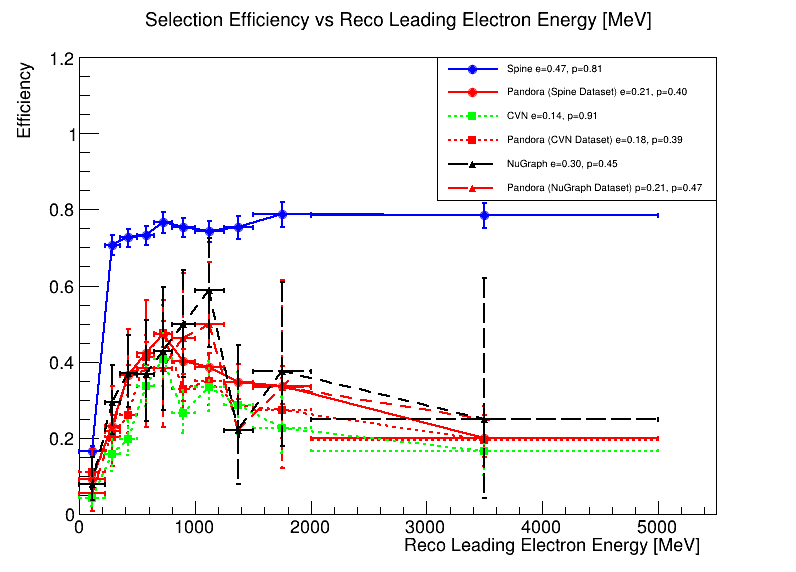

In [77]:
c1 = r.TCanvas("c1", "c1", 800, 600)

h_spine_eff.SetLineColor(r.kBlue)
h_spine_eff.SetLineWidth(2)
h_spine_eff.SetMarkerStyle(20)
h_spine_eff.SetMarkerColor(r.kBlue)

h_cvn_eff.SetLineColor(r.kGreen)
h_cvn_eff.SetLineWidth(2)
h_cvn_eff.SetLineStyle(2)
h_cvn_eff.SetMarkerStyle(21)
h_cvn_eff.SetMarkerColor(r.kGreen)

h_nuGraph_eff.SetLineColor(r.kBlack)
h_nuGraph_eff.SetLineWidth(2)
h_nuGraph_eff.SetLineStyle(9)
h_nuGraph_eff.SetMarkerStyle(22)

h_pandoraCVN_eff.SetLineColor(r.kRed)
h_pandoraCVN_eff.SetLineWidth(2)
h_pandoraCVN_eff.SetLineStyle(2)
h_pandoraCVN_eff.SetMarkerStyle(21)
h_pandoraCVN_eff.SetMarkerColor(r.kRed)

h_pandora_eff.SetLineColor(r.kRed)
h_pandora_eff.SetLineWidth(2)
h_pandora_eff.SetMarkerStyle(20)
h_pandora_eff.SetMarkerColor(r.kRed)

h_pandoraNu_eff.SetLineColor(r.kRed)
h_pandoraNu_eff.SetLineWidth(2)
h_pandoraNu_eff.SetLineStyle(9)
h_pandoraNu_eff.SetMarkerStyle(22)
h_pandoraNu_eff.SetMarkerColor(r.kRed)

h_spine_eff.SetTitle("Selection Efficiency vs Reco Leading Electron Energy [MeV]; Reco Leading Electron Energy [MeV]; Efficiency")
h_spine_eff.GetYaxis().SetRangeUser(0, 1.2)

h_spine_eff.Draw("")
h_pandora_eff.Draw("PL same")
h_pandoraNu_eff.Draw("PL same")
h_pandoraCVN_eff.Draw("PL same")
h_cvn_eff.Draw("PL same")
h_nuGraph_eff.Draw("PL same")
e_pandora = pandora_selections[-1].efficiency

l = r.TLegend(0.55, 0.65, 0.9, 0.9)
l.AddEntry(h_spine_eff, f'Spine e={e_spine:.2f}, p={p_spine:.2f}', 'lp')
l.AddEntry(h_pandora_eff, f'Pandora (Spine Dataset) e={e_pandora:.2f}, p={p_pandora:.2f}', 'lp')
l.AddEntry(h_cvn_eff, f'CVN e={e_cvn:.2f}, p={p_cvn:.2f}', 'lp')
l.AddEntry(h_pandoraCVN_eff, f'Pandora (CVN Dataset) e={e_pandoraCVN:.2f}, p={p_pandoraCVN:.2f}', 'lp')
l.AddEntry(h_nuGraph_eff, f'NuGraph e={e_nu:.2f}, p={p_nu:.2f}', 'lp')
l.AddEntry(h_pandoraNu_eff, f'Pandora (NuGraph Dataset) p={e_pandoraNu:.2f}, p={p_pandoraNu:.2f}', 'lp')

l.Draw()

c1.SetLogy(0)
c1.Draw()

%jsroot off

In [112]:
c1 = r.TCanvas("c1", "c1", 800, 600)
c1.cd()

fin = r.TFile.Open('root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine8/output_merged.root')
tree = fin.Get('events/NuMIFull/selected')

# draw 2D histogram: "y:x>>h(nx,xmin,xmax,ny,ymin,ymax)"
tree.Draw("true_category:true_interaction_mode>>h(10,0,10,10,0,10)", "", "COLZ")

c1.Update()
h = r.gPad.GetPrimitive("h")
h.Draw("colz text")
c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


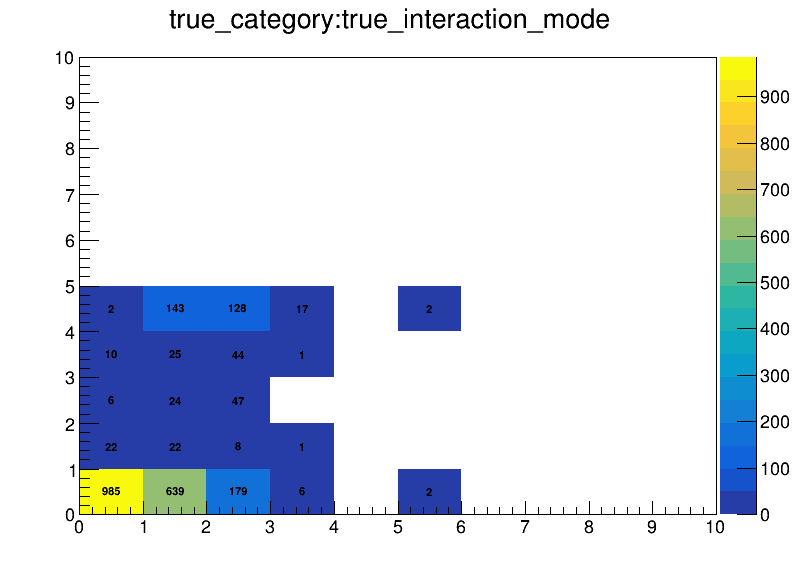

In [111]:
c1.Draw()

In [122]:
fin = uproot.open('root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine8/output_merged.root:events/NuMIFull/selected')

true = fin['true_category'].array()
inter = fin['true_interaction_mode'].array()

out = np.where(true==0, inter, -1)

In [123]:
out[ak.where(out>=0)]

<Array [0, 1, 2, 2, 0, 1, 0, ..., 0, 0, 0, 0, 0, 1, 0] type='2111 * float64'>